# Tarea 2 — Detección de Contribuciones (v5)
## Proyecto FLAG · Grupo 2 · MAIA 2026

Quinta iteración. Cambios respecto a v4:

| Aspecto | v4 (ejecutado) | v5 (este notebook) |
|---|---|---|
| Few-shot examples | 4 (2 SI + 2 NO) seleccionados automáticamente vía `find_example()` heurística | **8 (4 SI + 4 NO) curados manualmente** por el equipo, orden alternado SI/NO |
| Selección | heurística por keywords del train | manual: dominios diversos (ML, biomedicina, química, multimodal) |
| `max_length` Llama few-shot | 3072 | 4096 (k=8 con ejemplos largos necesita más contexto) |
| Reproducibilidad | ejemplos no documentados | SHA256 publicado en `release_manifest.json`; hardcoded idénticos en notebook ↔ backend |
| `model_id` LLM few-shot | `*-fs4` | `*-fs8` |
| Costo GPT few-shot esperado | $0.016 USD (k=4 ejemplos cortos) | $0.036 USD (k=8 ejemplos más largos), ~2× |

### Resultados de referencia (de v4 ejecutado)

| # | Modelo | F1 macro v4 | IC 95% v4 | Esperado en v5 |
|---|---|---|---|---|
| 1 | SciBETO baseline | 0.852 | [0.793, 0.900] | sin cambio (no afecta a SciBETOs) |
| 2 | SciBETO + ctx | 0.798 | [0.736, 0.858] | sin cambio |
| 3 | Llama 3.1 8B zero-shot | 0.393 | [0.338, 0.454] | sin cambio |
| 4 | Llama 3.1 8B few-shot (k=4 → k=8) | 0.561 | [0.489, 0.632] | **0.62-0.68** (estimado) |
| 5 | GPT-4o-mini zero-shot | 0.423 | [0.361, 0.493] | sin cambio |
| 6 | GPT-4o-mini few-shot (k=4 → k=8) | 0.534 | [0.464, 0.609] | **0.60-0.66** (estimado) |

### Modelos evaluados (6 puntos de comparación)

| # | Modelo | Tipo | model_id en backend |
|---|---|---|---|
| 1 | SciBETO-large (text-only) | encoder fine-tuned | `scibert-es-t2` |
| 2 | SciBETO-large + contexto | encoder fine-tuned | `scibert-es-t2-ctx` |
| 3 | Llama 3.1 8B (zero-shot) | open-weight | `llama-3.1-8b-t2` |
| 4 | **Llama 3.1 8B (few-shot k=8)** | open-weight | `llama-3.1-8b-t2-fs8` |
| 5 | GPT-4o-mini (zero-shot) | comercial API | `gpt-4o-mini-t2` |
| 6 | **GPT-4o-mini (few-shot k=8)** | comercial API | `gpt-4o-mini-t2-fs8` |

### Toggle de re-entrenamiento

Si ya entrenaste los SciBETOs en una corrida anterior (v3 o v4) y los pesos
están en `MODEL_OUT_BASE` y `MODEL_OUT_CTX`, podés saltar el reentrenamiento:

```python
RETRAIN_SCIBETOS = False   # ← reusa pesos existentes (ahorra ~35 min)
```

El notebook detecta automáticamente si los pesos existen y los carga.
Las celdas LLM (que son lo nuevo en v5) siempre se re-ejecutan.

Tiempo estimado Colab T4 con `RETRAIN_SCIBETOS=False`: **~20 min** (solo LLMs).
Con `RETRAIN_SCIBETOS=True`: ~75 min.


---
## 1. Instalación de dependencias

In [1]:
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

pip_install(
    "transformers>=4.45.0", "torch>=2.4.0", "accelerate>=0.33.0",
    "bitsandbytes>=0.43.0",
    "scikit-learn", "pandas", "matplotlib", "seaborn",
    "wandb", "openai>=1.47.0", "tqdm",
)

---
## 2. Configuración global

**Toggle W&B**: cambiá `WB_ENABLED = False` si querés desactivar logging a W&B
sin tocar más nada. El notebook funciona idéntico con W&B apagado, solo
omitirá los `wandb.init()` y `wandb.log()`.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os, json, time, random, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm.auto import tqdm

# ─── Credenciales desde Colab Secrets ─────────────────────────────────────────
try:
    from google.colab import userdata
    OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")
    HF_TOKEN       = userdata.get("HF_TOKEN")
    WANDB_API_KEY  = userdata.get("WANDB_API_KEY")
except Exception:
    OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "")
    HF_TOKEN       = os.environ.get("HF_TOKEN", "")
    WANDB_API_KEY  = os.environ.get("WANDB_API_KEY", "")

# ─── W&B toggle ──────────────────────────────────────────────────────────────
WB_ENABLED = True   # ← cambia a False para apagar W&B sin tocar más nada

if WB_ENABLED:
    if not WANDB_API_KEY:
        print("⚠️ WB_ENABLED=True pero no hay WANDB_API_KEY en Colab Secrets.")
        print("   Configurarla en 🔑 Secrets o setear WB_ENABLED=False.")
        WB_ENABLED = False
    else:
        import wandb
        os.environ["WANDB_API_KEY"] = WANDB_API_KEY
        wandb.login(key=WANDB_API_KEY)
        os.environ["WANDB_PROJECT"] = "maia-flag-document-analysis"
        os.environ["WANDB_ENTITY"]  = "natamoncada10-universidad-de-los-andes"
        print("✓ W&B habilitado")

# HF login para Llama gated
if HF_TOKEN:
    from huggingface_hub import login
    login(token=HF_TOKEN)
    print("✓ HF login OK")
else:
    print("⚠️ HF_TOKEN no configurado — la carga de Llama 3.1 fallará en §8")

# ─── Rutas ───────────────────────────────────────────────────────────────────
DRIVE_ROOT = "/content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab"

# T2 datasets — gold humano vive en {DRIVE_ROOT}/maia_datasets/t2/
TRAIN_PATH     = f"{DRIVE_ROOT}/maia_datasets/t2/train.jsonl"
VAL_PATH       = f"{DRIVE_ROOT}/maia_datasets/t2/val.jsonl"
TEST_PATH      = f"{DRIVE_ROOT}/maia_datasets/t2/anotacion_referencia.csv"
AGREEMENT_PATH = f"{DRIVE_ROOT}/maia_datasets/t2/acuerdo_interanotador.json"

# T1 V5 ya entrenado (path correcto)
T1_MODEL_PATH = f"{DRIVE_ROOT}/scibeto-v5-cris"

# Outputs — los dos modelos T2 van a estos paths
MODEL_OUT_BASE = f"{DRIVE_ROOT}/scibert-es-t2"      # baseline text-only
MODEL_OUT_CTX  = f"{DRIVE_ROOT}/scibert-es-t2-ctx"  # con prefijo contextual

# Cache de T1 inference
CACHE_DIR = f"{DRIVE_ROOT}/cache_t1_inference"
os.makedirs(CACHE_DIR, exist_ok=True)

# Release de modelos (ZIPs + SHA256)
RELEASE_DIR = f"{DRIVE_ROOT}/models_release"
os.makedirs(RELEASE_DIR, exist_ok=True)

# ─── Toggles de ejecución ─────────────────────────────────────────────────────
# Si True, re-entrena SciBETOs de cero (~35 min).
# Si False, carga pesos desde MODEL_OUT_BASE / MODEL_OUT_CTX si existen.
#   Si los pesos no existen, fuerza re-entrenamiento aunque sea False.
RETRAIN_SCIBETOS = True

# W&B labels
WB_PROJECT = "maia-flag-document-analysis"
WB_ENTITY  = "natamoncada10-universidad-de-los-andes"
WB_GROUP   = "task2-v5-fewshot-k8"

# Reproducibilidad
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
sns.set_theme(style="whitegrid", palette="muted")

print(f"\n✓ Configuración lista")
print(f"  W&B enabled  : {WB_ENABLED}")
print(f"  W&B group    : {WB_GROUP}")
print(f"  Test path    : {TEST_PATH}")
print(f"  Agreement    : {AGREEMENT_PATH}")
print(f"  T1 model     : {T1_MODEL_PATH}")
print(f"  Baseline out : {MODEL_OUT_BASE}")
print(f"  Ctx out      : {MODEL_OUT_CTX}")
print(f"  Release ZIPs : {RELEASE_DIR}")
print(f"  RETRAIN_SCIBETOS = {RETRAIN_SCIBETOS}")
print(f"  Device       : {'CUDA ✓' if torch.cuda.is_available() else 'CPU ⚠️'}")
if torch.cuda.is_available():
    print(f"  GPU          : {torch.cuda.get_device_name(0)}")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: edwincifuentes (natamoncada10-universidad-de-los-andes) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✓ W&B habilitado
✓ HF login OK

✓ Configuración lista
  W&B enabled  : True
  W&B group    : task2-v5-fewshot-k8
  Test path    : /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/maia_datasets/t2/anotacion_referencia.csv
  Agreement    : /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/maia_datasets/t2/acuerdo_interanotador.json
  T1 model     : /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/scibeto-v5-cris
  Baseline out : /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/scibert-es-t2
  Ctx out      : /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/scibert-es-t2-ctx
  Release ZIPs : /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Solucion

---
## 3. Carga de datos

Train y val son JSONL silver. Test es CSV humano con 200 fragmentos. Más
adelante el test gold se reduce a los **170 con consenso interanotador** según
`acuerdo_interanotador.json`.

In [4]:
def load_jsonl(path: str) -> pd.DataFrame:
    records = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return pd.DataFrame(records)


def load_test_csv(path: str) -> pd.DataFrame:
    """
    Carga anotacion_referencia.csv. Esperamos que traiga al menos:
      - id, snippet, auto_label (o a1_class), relative_pos, word_count
    """
    df = pd.read_csv(path, encoding="utf-8")
    df = df.rename(columns={
        "snippet"      : "text",
        "auto_label"   : "a1_class",
        "a1_class_auto": "a1_label",
    })
    df["a1_class"] = pd.to_numeric(df["a1_class"], errors="coerce").fillna(0).astype(int)
    if "a1_label" not in df.columns:
        df["a1_label"] = df["a1_class"].map({1:"ES_CONTRIBUCION", 0:"NO_ES_CONTRIBUCION"})
    if "word_count" not in df.columns or df["word_count"].isna().all():
        df["word_count"] = df["text"].str.split().str.len()
    return df


# Cargar las 3 particiones
df_train_raw = load_jsonl(TRAIN_PATH)
df_val_raw   = load_jsonl(VAL_PATH)
df_test_raw  = load_test_csv(TEST_PATH)

# Normalización mínima — clip relative_pos a [0,1] y reconstruir a1_class si falta
for df in [df_train_raw, df_val_raw, df_test_raw]:
    if "relative_pos" in df.columns:
        df["relative_pos"] = pd.to_numeric(df["relative_pos"], errors="coerce").clip(0, 1)
    if "a1_class" not in df.columns:
        df["a1_class"] = (df["a1_label"] == "ES_CONTRIBUCION").astype(int)
    if "word_count" not in df.columns:
        df["word_count"] = df["text"].astype(str).str.split().str.len()
    # Eliminar t1_label si vino del dataset — lo vamos a inferir nosotros
    if "t1_label" in df.columns:
        df.drop(columns=["t1_label"], inplace=True)

# ─── DIAGNÓSTICO automático del dataset ───────────────────────────────────────
print(f"\n{'='*72}")
print(f"  Diagnóstico de splits cargados")
print(f"{'='*72}")

DIAGNOSTIC_ERRORS = []

for name, df in [("train", df_train_raw), ("val", df_val_raw), ("test", df_test_raw)]:
    pos = df["a1_class"].sum(); neg = (df["a1_class"]==0).sum()
    pos_pct = pos / len(df) * 100

    print(f"\n  {name}: n={len(df):,} | ES_CONTR={pos:,} ({pos_pct:.1f}%) | NO_CONTR={neg:,}")

    # Check 1: relative_pos no degenerada
    if "relative_pos" in df.columns:
        rp_min, rp_max, rp_std = df["relative_pos"].min(), df["relative_pos"].max(), df["relative_pos"].std()
        print(f"        relative_pos ∈ [{rp_min:.3f}, {rp_max:.3f}] σ={rp_std:.3f}")
        if rp_max - rp_min < 0.05:
            err = f"❌ {name}: relative_pos casi constante (rango={rp_max-rp_min:.3f}). Probable bug del dataset."
            DIAGNOSTIC_ERRORS.append(err)
            print(f"        {err}")
    else:
        err = f"❌ {name}: falta columna relative_pos"
        DIAGNOSTIC_ERRORS.append(err)
        print(f"        {err}")

    # Check 2: balance no extremo
    if pos_pct < 5 or pos_pct > 95:
        err = f"⚠️ {name}: balance extremo {pos_pct:.1f}% positivos"
        DIAGNOSTIC_ERRORS.append(err)
        print(f"        {err}")

# Check 3: columna id en test
if "id" not in df_test_raw.columns:
    err = "❌ test: falta columna 'id' — no se puede mergear con acuerdo_interanotador.json"
    DIAGNOSTIC_ERRORS.append(err)
    print(f"\n  {err}")
else:
    print(f"\n  ✓ test trae columna 'id', sample: {df_test_raw['id'].iloc[0]}")

if DIAGNOSTIC_ERRORS:
    print(f"\n{'='*72}")
    print(f"  ⚠️ {len(DIAGNOSTIC_ERRORS)} problemas detectados:")
    for e in DIAGNOSTIC_ERRORS:
        print(f"    {e}")
    print(f"  Revisar antes de continuar.")
    print(f"{'='*72}")
else:
    print(f"\n  🟢 Diagnóstico OK — datasets parecen sanos")


  Diagnóstico de splits cargados

  train: n=1,600 | ES_CONTR=794 (49.6%) | NO_CONTR=806
        relative_pos ∈ [0.000, 0.976] σ=0.244

  val: n=400 | ES_CONTR=206 (51.5%) | NO_CONTR=194
        relative_pos ∈ [0.000, 0.956] σ=0.247

  test: n=200 | ES_CONTR=100 (50.0%) | NO_CONTR=100
        relative_pos ∈ [0.000, 0.956] σ=0.254

  ✓ test trae columna 'id', sample: T2-0001

  🟢 Diagnóstico OK — datasets parecen sanos


---
## 4. Carga de `acuerdo_interanotador.json` y construcción del test gold

El JSON contiene:
- `cohen_kappa: 0.6995` — acuerdo sustancial (κ ≥ 0.60 según interpretación Landis-Koch, cumple requisito FLAG)
- `consensus.labels`: 170 IDs con consenso, con su label binaria validada
- `disagreement_ids`: 30 IDs donde A1 y A2 no coincidieron

**Subsets resultantes:**

| Subset | n | Uso |
|---|---|---|
| `df_test_170` | 170 | **Métricas oficiales del paper** |
| `df_test_30` | 30 | Análisis cualitativo (sin label, no métricas) |

In [5]:
# Cargar JSON de acuerdo
with open(AGREEMENT_PATH, encoding="utf-8") as f:
    agreement = json.load(f)

KAPPA               = agreement["cohen_kappa"]
KAPPA_INTERPRET     = agreement["kappa_interpretation"]
KRIPP_ALPHA         = agreement.get("krippendorff_alpha", KAPPA)
N_FRAGMENTS         = agreement["n_fragments"]
PCT_AGREEMENT       = agreement["percent_agreement"]
CONSENSUS_LABELS    = agreement["consensus"]["labels"]   # dict ID → 0/1
DISAGREEMENT_IDS    = set(agreement["disagreement_ids"]) # set de IDs

print(f"\n{'='*72}")
print(f"  Acuerdo Interanotador")
print(f"{'='*72}")
print(f"  Total fragmentos     : {N_FRAGMENTS}")
print(f"  Cohen's κ            : {KAPPA:.4f} ({KAPPA_INTERPRET})")
print(f"  Krippendorff's α     : {KRIPP_ALPHA:.4f}")
print(f"  % acuerdo simple     : {PCT_AGREEMENT}%")
print(f"  Con consenso         : {len(CONSENSUS_LABELS)} fragmentos")
print(f"  Sin consenso (amb.)  : {len(DISAGREEMENT_IDS)} fragmentos")

# Sanity checks
assert N_FRAGMENTS == len(df_test_raw), f"JSON dice {N_FRAGMENTS} pero CSV trae {len(df_test_raw)}"
assert len(CONSENSUS_LABELS) + len(DISAGREEMENT_IDS) == N_FRAGMENTS, \
    "Los con-consenso y los ambiguos no suman al total"
assert len(set(CONSENSUS_LABELS.keys()) & DISAGREEMENT_IDS) == 0, \
    "Algún ID está tanto en consensus como en disagreement"

# Mergear por id
df_test_raw["consensus_label"] = df_test_raw["id"].map(CONSENSUS_LABELS)
df_test_raw["is_ambiguous"]    = df_test_raw["id"].isin(DISAGREEMENT_IDS)

# Validar que cada fragmento del CSV está en una de las dos categorías
unmapped = df_test_raw[
    df_test_raw["consensus_label"].isna() & ~df_test_raw["is_ambiguous"]
]
assert len(unmapped) == 0, f"{len(unmapped)} fragmentos del CSV no están en el JSON: {unmapped['id'].tolist()[:5]}"

# Construir los dos subsets
df_test_170 = df_test_raw[~df_test_raw["is_ambiguous"]].copy().reset_index(drop=True)
df_test_30  = df_test_raw[df_test_raw["is_ambiguous"]].copy().reset_index(drop=True)

# CRÍTICO: para df_test_170, la label que se usa para métricas es consensus_label (del JSON)
# NO a1_class (que puede ser de un solo anotador, distinto del consenso)
df_test_170["a1_class"] = df_test_170["consensus_label"].astype(int)
df_test_170["a1_label"] = df_test_170["a1_class"].map({1:"ES_CONTRIBUCION", 0:"NO_ES_CONTRIBUCION"})

assert len(df_test_170) == 170, f"Esperaba 170, tengo {len(df_test_170)}"
assert len(df_test_30)  == 30,  f"Esperaba 30, tengo {len(df_test_30)}"
assert df_test_170["consensus_label"].isna().sum() == 0
assert df_test_30["consensus_label"].isna().sum() == 30

n_pos_170 = df_test_170["a1_class"].sum()
n_neg_170 = (df_test_170["a1_class"] == 0).sum()
print(f"\n  ✓ df_test_170 construido: ES_CONTR={n_pos_170} | NO_CONTR={n_neg_170} (balance={n_pos_170/170*100:.1f}%)")
print(f"  ✓ df_test_30 construido (sin label para métricas)")


  Acuerdo Interanotador
  Total fragmentos     : 200
  Cohen's κ            : 0.6995 (Sustancial  ← mínimo requerido por el proyecto)
  Krippendorff's α     : 0.6995
  % acuerdo simple     : 85.0%
  Con consenso         : 170 fragmentos
  Sin consenso (amb.)  : 30 fragmentos

  ✓ df_test_170 construido: ES_CONTR=81 | NO_CONTR=89 (balance=47.6%)
  ✓ df_test_30 construido (sin label para métricas)


### Gráfica 1 — Distribución de splits

Sanity check visual: balance pos/neg + distribución de `relative_pos` por split.

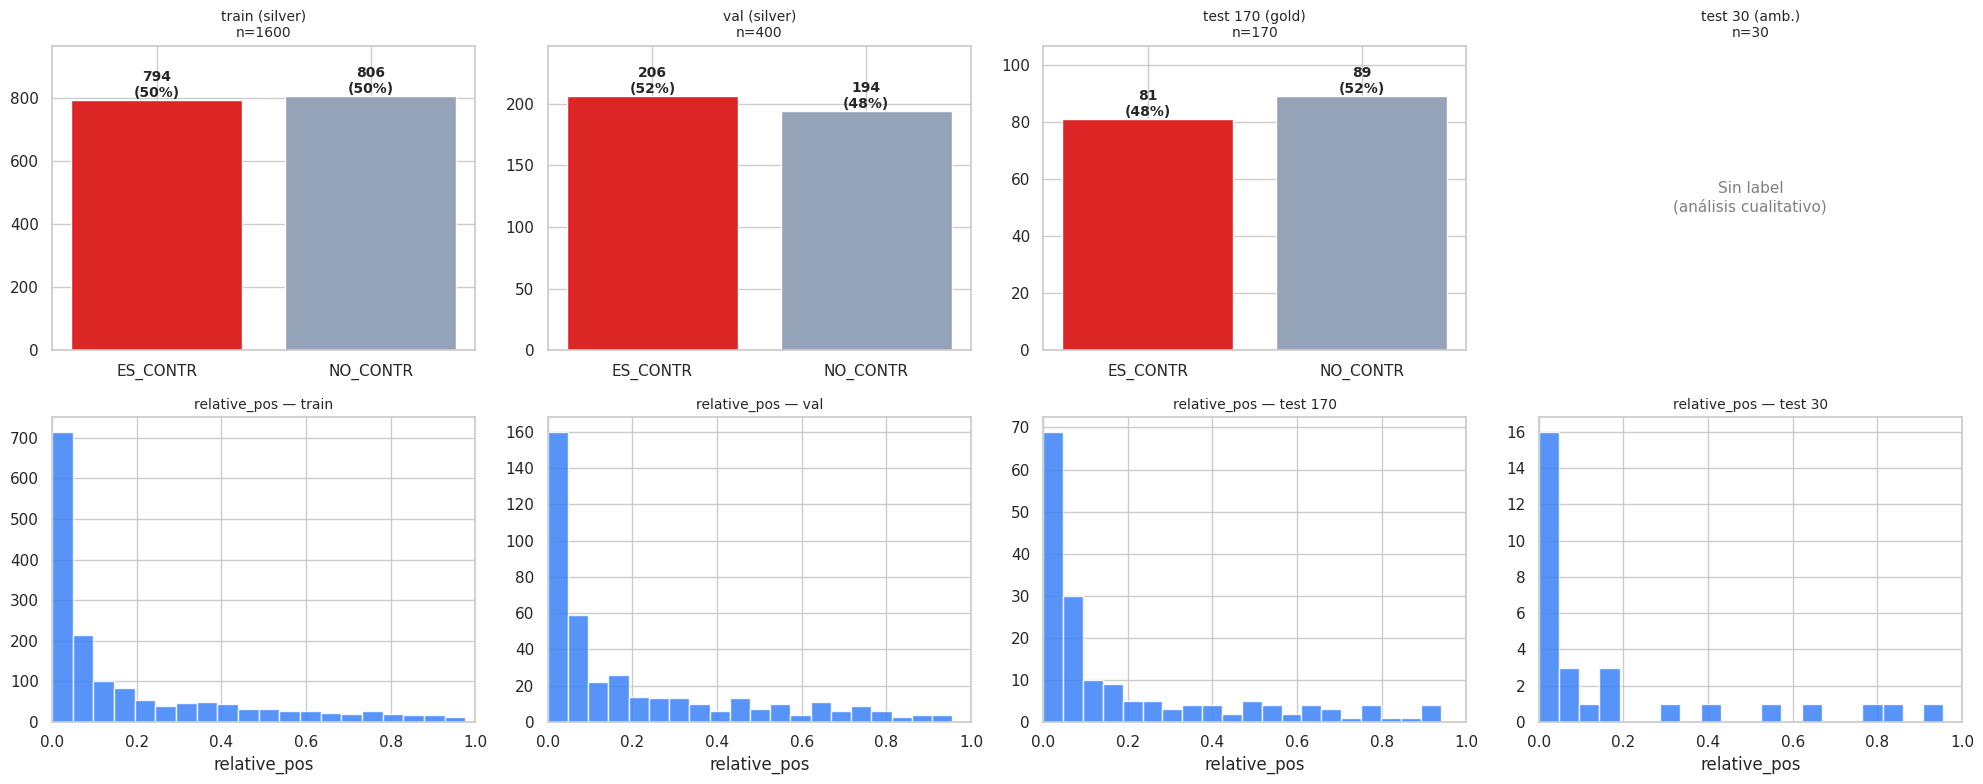

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

# Fila 1: Balance pos/neg
for ax, (name, df) in zip(axes[0], [
    ("train (silver)", df_train_raw),
    ("val (silver)",   df_val_raw),
    ("test 170 (gold)",df_test_170),
    ("test 30 (amb.)", df_test_30),
]):
    if name == "test 30 (amb.)":
        ax.text(0.5, 0.5, "Sin label\n(análisis cualitativo)", ha="center", va="center",
                fontsize=11, transform=ax.transAxes, color="gray")
        ax.set_title(f"{name}\nn={len(df)}", fontsize=10)
        ax.axis("off")
        continue
    pos = (df["a1_class"] == 1).sum(); neg = (df["a1_class"] == 0).sum()
    bars = ax.bar(["ES_CONTR","NO_CONTR"], [pos, neg], color=["#dc2626","#94a3b8"], edgecolor="white")
    for b, v in zip(bars, [pos, neg]):
        ax.text(b.get_x()+b.get_width()/2, v, f"{v}\n({v/len(df)*100:.0f}%)",
                ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(f"{name}\nn={len(df)}", fontsize=10)
    ax.set_ylim(0, max(pos, neg) * 1.2)

# Fila 2: Distribución de relative_pos
for ax, (name, df) in zip(axes[1], [
    ("train",  df_train_raw),
    ("val",    df_val_raw),
    ("test 170", df_test_170),
    ("test 30",  df_test_30),
]):
    if "relative_pos" in df.columns:
        ax.hist(df["relative_pos"].dropna(), bins=20, color="#3b82f6",
                edgecolor="white", alpha=0.85)
        ax.set_xlim(0, 1)
        ax.set_title(f"relative_pos — {name}", fontsize=10)
        ax.set_xlabel("relative_pos")
        rng = df["relative_pos"].max() - df["relative_pos"].min()
        if rng < 0.05:
            ax.text(0.5, 0.5, f"⚠️ DEGENERADO\nrango={rng:.3f}",
                    ha="center", va="center", color="red", fontsize=12,
                    transform=ax.transAxes, fontweight="bold")
    else:
        ax.text(0.5, 0.5, "sin relative_pos", ha="center", va="center",
                transform=ax.transAxes, color="gray")
        ax.set_title(f"{name}")

plt.tight_layout()
plt.savefig("/tmp/g1_splits_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 5. Inferencia T1 V5 sobre splits

T1 V5 entrenó con preprocessing dinámico (regex extractor + máscara de
keywords). Para que el `t1_label` predicho sea consistente con cómo se
entrenó T1, aplicamos exactamente ese preprocessing antes de pasar cada
fragmento al encoder.

**Cache.** El resultado se guarda en
`{DRIVE_ROOT}/cache_t1_inference/{split}_v3.jsonl`. Si el cache existe y
tiene el tamaño correcto, se salta el paso (~20 min ahorrados).

In [7]:
import re

# ─── Preprocessing T1 (idéntico al de producción) ─────────────────────────────
THRESHOLDS = {"DISC": 2, "CONC": 2, "INTRO": 3, "LIM": 2, "BACK": 3, "METH": 4, "RES": 4}
DEFAULT_THRESHOLD = 2

REGEX_PATTERNS = {
    "INTRO": re.compile(
        r'\b(objetivo\sgeneral|objetivo\sprincipal|el\sobjetivo\sde\s(?:este|esta)|'
        r'problema\sde\sinvestigaci[oó]n|introducci[oó]n|justificaci[oó]n|'
        r'prop[oó]sito\sprincipal|planteamiento\sdel\sproblema|'
        r'el\spresente\strabajo\s(?:aborda|tiene\scomo|se\scentra)|'
        r'la\sfinalidad\sde\s(?:este|esta)|hip[oó]tesis\sde\strabajo)\b',
        re.IGNORECASE),
    "BACK": re.compile(
        r'\b(antecedentes|estado\sdel\sarte|trabajos\sprevios|marco\ste[oó]rico|'
        r'estudios\sprevios|investigaciones\sprevias|revisi[oó]n\sbibliogr[aá]fica|'
        r'literatura\scient[ií]fica|trabajo\srelacionado|et\sal\.|seg[uú]n\s[A-Z][a-z]+|'
        r'estudios\santeriores|tradicionalmente)\b', re.IGNORECASE),
    "METH": re.compile(
        r'\b(metodolog[íi]a|dise[ñn]o\smetodol[oó]gico|dise[ñn]o\sde\sinvestigaci[oó]n|'
        r'materiales\sy\sm[eé]todos|poblaci[oó]n\sy\smuestra|criterios\sde\sinclusi[oó]n|'
        r'instrumentos\sde\srecolecci[oó]n|an[aá]lisis\sestad[íi]stico|'
        r'enfoque\scuantitativo|enfoque\scualitativo|variables\sdependientes|'
        r'variables\sindependientes)\b', re.IGNORECASE),
    "RES":  re.compile(
        r'\b(resultados|hallazgos|los\sresultados\smuestran|los\sresultados\sindican|'
        r'se\sencontró\sque|se\sobservó\sque|estadísticamente\ssignificativo|'
        r'valor\sde\sp|intervalo\sde\sconfianza|desviación\sestándar|'
        r'un\saumento\sde|una\sreducción\sde)\b', re.IGNORECASE),
    "DISC": re.compile(
        r'\b(discusi[oó]n|interpretaci[oó]n\sde\slos\sresultados|coincide\scon|'
        r'consistente\scon|a\sdiferencia\sde|estos\sresultados\ssugieren|'
        r'estos\shallazgos|esto\simplica\sque|esto\sse\sdebe\sa|'
        r'podr[ií]a\sexplicarse\spor|abre\snuevas\sperspectivas)\b', re.IGNORECASE),
    "LIM": re.compile(
        r'\b(limitaci[oó]n|limitaciones|no\sfue\sposible|sesgo|tama[ñn]o\smuestral|'
        r'muestra\speque[ñn]a|futuras\sinvestigaciones|trabajo\sfuturo|'
        r'queda\spendiente|debe\sinterpretarse\scon\scautela)\b', re.IGNORECASE),
    "CONC": re.compile(
        r'\b(conclusiones|conclusi[oó]n|en\sconclusi[oó]n|se\sconcluye\sque|'
        r'en\sresumen|en\sdefinitiva|este\sestudio\sha\sdemostrado|'
        r'este\strabajo\saporta\sevidencia|finalmente)\b', re.IGNORECASE),
}

MASK_TOKEN = "[MASK]"

def compute_matched_keywords(snippet):
    scores, matches_dict = {}, {}
    for cat, pat in REGEX_PATTERNS.items():
        matches = pat.findall(snippet)
        min_required = THRESHOLDS.get(cat, DEFAULT_THRESHOLD)
        if len(matches) >= min_required:
            scores[cat] = len(matches)
            matches_dict[cat] = list(set([
                (m.lower() if isinstance(m, str) else m[0].lower()) for m in matches
            ]))
    if scores:
        best = max(scores, key=scores.get)
        return matches_dict[best]
    return []

def apply_dynamic_mask(snippet, matched_keywords):
    if not matched_keywords:
        return re.sub(r'\s+', ' ', str(snippet)).strip()
    out = str(snippet)
    for kw in sorted(matched_keywords, key=len, reverse=True):
        out = re.sub(rf'\b{re.escape(kw)}\b', MASK_TOKEN, out, flags=re.IGNORECASE)
    return re.sub(r'\s+', ' ', out).strip()

def preprocess_for_t1(snippet):
    return apply_dynamic_mask(snippet, compute_matched_keywords(snippet))

print("✓ Preprocessing T1 cargado")

✓ Preprocessing T1 cargado


In [8]:
# ─── Cargar T1 V5 una sola vez ────────────────────────────────────────────
from transformers import AutoTokenizer, AutoModelForSequenceClassification

print(f"Cargando T1 V5 desde {T1_MODEL_PATH}...")
t1_tok = AutoTokenizer.from_pretrained(T1_MODEL_PATH)
t1_model = AutoModelForSequenceClassification.from_pretrained(T1_MODEL_PATH)
t1_model.eval()
if torch.cuda.is_available():
    t1_model = t1_model.cuda().half()
    print(f"  T1 en GPU + FP16")

T1_ID2LABEL = t1_model.config.id2label
print(f"  T1 id2label: {T1_ID2LABEL}")


@torch.no_grad()
def predict_t1_batch(texts, batch_size=32, desc="T1 inference"):
    preds, confs = [], []
    for i in tqdm(range(0, len(texts), batch_size), desc=desc):
        chunk = [preprocess_for_t1(t) for t in texts[i:i+batch_size]]
        enc = t1_tok(chunk, truncation=True, max_length=512,
                     padding=True, return_tensors="pt")
        if torch.cuda.is_available():
            enc = {k: v.cuda() for k, v in enc.items()}
        logits = t1_model(**enc).logits
        probs = torch.softmax(logits.float(), dim=-1).cpu().numpy()
        ids = probs.argmax(axis=-1)
        for j, idx in enumerate(ids):
            preds.append(T1_ID2LABEL[int(idx)])
            confs.append(float(probs[j, idx]))
    return preds, confs

Cargando T1 V5 desde /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/scibeto-v5-cris...


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

  T1 en GPU + FP16
  T1 id2label: {0: 'INTRO', 1: 'BACK', 2: 'METH', 3: 'RES', 4: 'DISC', 5: 'LIM', 6: 'CONC'}


In [9]:
# ─── Enriquecer cada split con t1_label (con cache) ───────────────────────

def enrich_with_t1(df, split_name, force=False):
    cache_path = f"{CACHE_DIR}/{split_name}_v3.jsonl"
    if os.path.exists(cache_path) and not force:
        df_cached = pd.read_json(cache_path, lines=True)
        if len(df_cached) == len(df) and "t1_label" in df_cached.columns:
            print(f"  ⏭️  Cache hit: {cache_path}")
            return df_cached
        print(f"  ⚠️ Cache stale, re-running ({len(df_cached)} vs {len(df)})")

    texts = df["text"].astype(str).tolist()
    t1_labels, t1_confs = predict_t1_batch(texts, batch_size=32, desc=f"T1 on {split_name}")
    df = df.copy()
    df["t1_label"] = t1_labels
    df["t1_confidence"] = t1_confs
    df.to_json(cache_path, orient="records", lines=True, force_ascii=False)
    print(f"  ✅ Cache guardado: {cache_path}")
    return df

print("\nInferencia T1 sobre los 3 splits efectivos:\n")
df_train    = enrich_with_t1(df_train_raw, "train")
df_val      = enrich_with_t1(df_val_raw,   "val")
df_test_170 = enrich_with_t1(df_test_170,  "test_170")
df_test_30  = enrich_with_t1(df_test_30,   "test_30")

# Liberar T1 de memoria
del t1_model, t1_tok
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("\n✅ T1 inference completada")


Inferencia T1 sobre los 3 splits efectivos:

  ⏭️  Cache hit: /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/cache_t1_inference/train_v3.jsonl
  ⏭️  Cache hit: /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/cache_t1_inference/val_v3.jsonl
  ⏭️  Cache hit: /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/cache_t1_inference/test_170_v3.jsonl
  ⏭️  Cache hit: /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/cache_t1_inference/test_30_v3.jsonl

✅ T1 inference completada


---
## 6. EDA del test gold (170)

### Gráfica 2 — Distribución T1 × T2 sobre los 170

Visualización clave: ¿dónde están concentradas las contribuciones según T1?
Si las 170 contribuciones están todas en INTRO+CONC, el contexto retórico
debería ayudar. Si están uniformemente distribuidas, el contexto aporta poco.

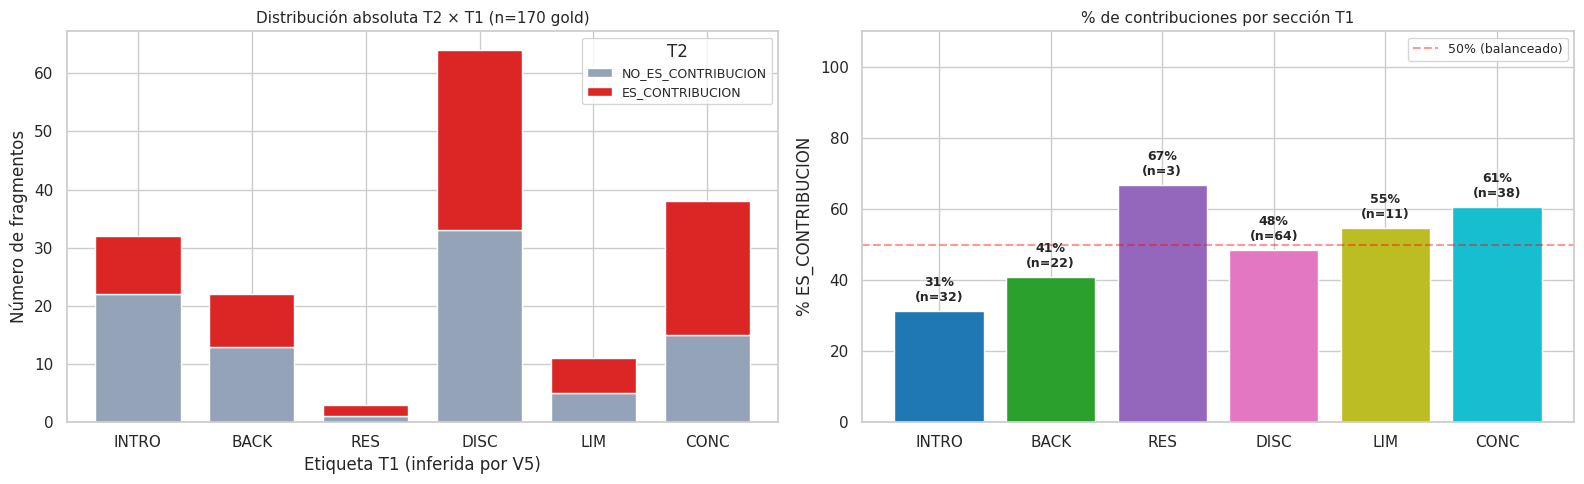


Distribución T1 × T2 sobre los 170 con consenso:
a1_label  NO_ES_CONTRIBUCION  ES_CONTRIBUCION  total  %_pos
t1_label                                                   
INTRO                     22               10     32   31.2
BACK                      13                9     22   40.9
RES                        1                2      3   66.7
DISC                      33               31     64   48.4
LIM                        5                6     11   54.5
CONC                      15               23     38   60.5


In [10]:
T1_ORDER = ["INTRO", "BACK", "METH", "RES", "DISC", "LIM", "CONC"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 1: barras apiladas
pivot = df_test_170.groupby(["t1_label","a1_label"]).size().unstack(fill_value=0)
pivot = pivot.reindex([t for t in T1_ORDER if t in pivot.index])
if "ES_CONTRIBUCION" not in pivot.columns: pivot["ES_CONTRIBUCION"] = 0
if "NO_ES_CONTRIBUCION" not in pivot.columns: pivot["NO_ES_CONTRIBUCION"] = 0
pivot = pivot[["NO_ES_CONTRIBUCION", "ES_CONTRIBUCION"]]

pivot.plot(kind="bar", stacked=True, ax=axes[0],
           color=["#94a3b8","#dc2626"], edgecolor="white", width=0.75)
axes[0].set_title("Distribución absoluta T2 × T1 (n=170 gold)", fontsize=11)
axes[0].set_xlabel("Etiqueta T1 (inferida por V5)")
axes[0].set_ylabel("Número de fragmentos")
axes[0].legend(title="T2", loc="upper right", fontsize=9)
axes[0].tick_params(axis="x", rotation=0)

# Subplot 2: % de positivos por sección
pivot_pct = pivot.copy()
pivot_pct["total"] = pivot_pct.sum(axis=1)
pivot_pct["pct_pos"] = pivot_pct["ES_CONTRIBUCION"] / pivot_pct["total"].replace(0,1) * 100
colors_t1 = plt.cm.tab10(np.linspace(0, 1, len(pivot_pct)))
bars = axes[1].bar(range(len(pivot_pct)), pivot_pct["pct_pos"], color=colors_t1, edgecolor="white")
for i, (idx, row) in enumerate(pivot_pct.iterrows()):
    axes[1].text(i, row["pct_pos"]+2, f"{row['pct_pos']:.0f}%\n(n={int(row['total'])})",
                 ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[1].set_xticks(range(len(pivot_pct)))
axes[1].set_xticklabels(pivot_pct.index)
axes[1].axhline(50, color="red", linestyle="--", alpha=0.4, label="50% (balanceado)")
axes[1].set_ylim(0, 110)
axes[1].set_title("% de contribuciones por sección T1", fontsize=11)
axes[1].set_ylabel("% ES_CONTRIBUCION")
axes[1].legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig("/tmp/g2_t1_t2_gold170.png", dpi=120, bbox_inches="tight")
plt.show()

# Tabla resumen
print("\nDistribución T1 × T2 sobre los 170 con consenso:")
pivot_print = pivot.copy()
pivot_print["total"] = pivot_print.sum(axis=1)
pivot_print["%_pos"] = (pivot_print["ES_CONTRIBUCION"] / pivot_print["total"] * 100).round(1)
print(pivot_print.to_string())

### Gráfica 3 — `relative_pos` por clase en el gold

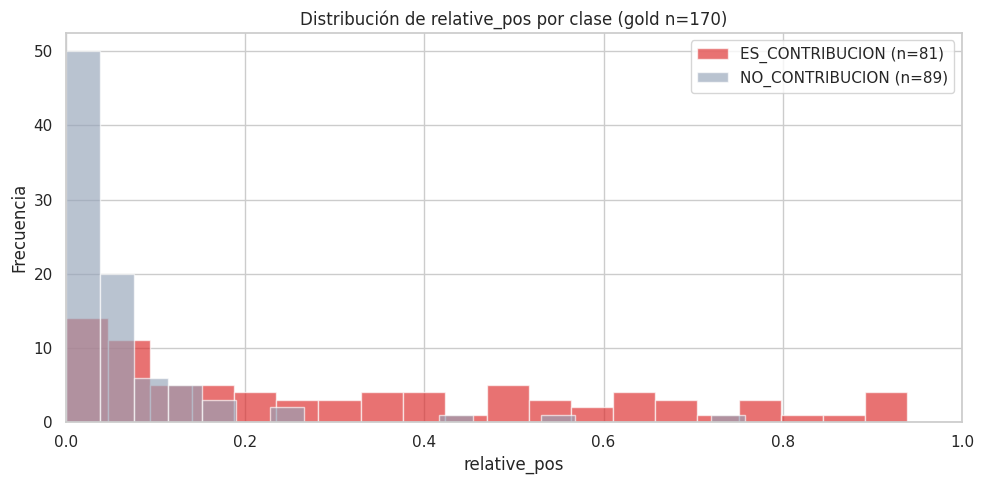

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
for cls, color, label in [(1, "#dc2626", "ES_CONTRIBUCION"), (0, "#94a3b8", "NO_CONTRIBUCION")]:
    subset = df_test_170[df_test_170["a1_class"] == cls]["relative_pos"]
    ax.hist(subset, bins=20, alpha=0.65, color=color, edgecolor="white", label=f"{label} (n={len(subset)})")
ax.set_xlabel("relative_pos")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de relative_pos por clase (gold n=170)")
ax.legend()
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig("/tmp/g3_relpos_gold170.png", dpi=120, bbox_inches="tight")
plt.show()

### Gráfica 4 — Longitud de fragmentos por clase

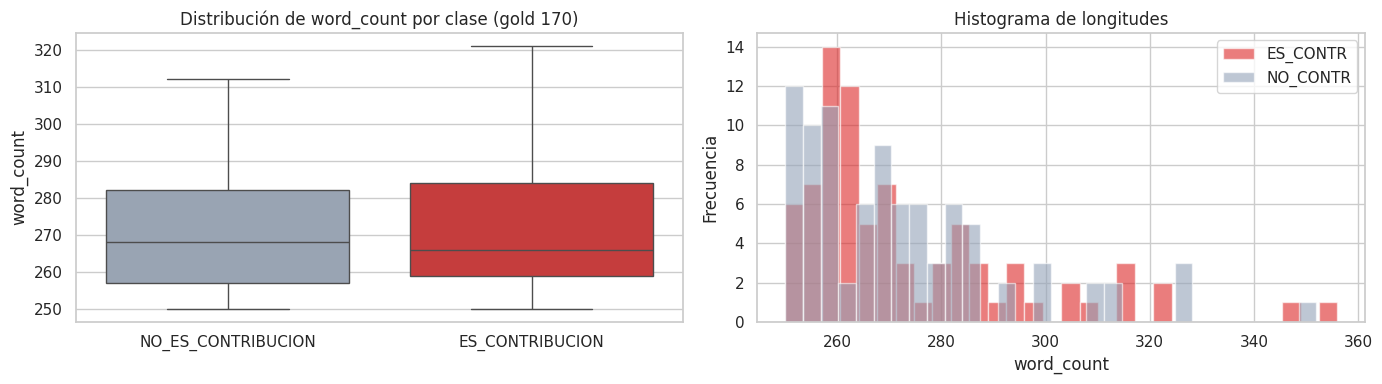


Estadísticas de word_count en gold 170:
                    count   mean   std    min    max
a1_label                                            
ES_CONTRIBUCION      81.0  273.7  21.8  250.0  356.0
NO_ES_CONTRIBUCION   89.0  272.3  20.6  250.0  352.0


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Boxplot
sns.boxplot(data=df_test_170, x="a1_label", y="word_count", ax=axes[0],
            hue="a1_label", palette={"ES_CONTRIBUCION":"#dc2626", "NO_ES_CONTRIBUCION":"#94a3b8"},
            legend=False, showfliers=False,
            order=["NO_ES_CONTRIBUCION","ES_CONTRIBUCION"])
axes[0].set_title("Distribución de word_count por clase (gold 170)")
axes[0].set_xlabel("")

# Histograma overlapping
for cls, color, label in [(1, "#dc2626", "ES_CONTR"), (0, "#94a3b8", "NO_CONTR")]:
    subset = df_test_170[df_test_170["a1_class"] == cls]["word_count"]
    axes[1].hist(subset, bins=30, alpha=0.6, color=color, edgecolor="white", label=label)
axes[1].set_xlabel("word_count")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Histograma de longitudes")
axes[1].legend()

plt.tight_layout()
plt.savefig("/tmp/g4_length_gold170.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nEstadísticas de word_count en gold 170:")
print(df_test_170.groupby("a1_label")["word_count"].describe().round(1)[["count","mean","std","min","max"]])

---
## 7. Construcción del prefijo de contexto

```
[SECCION:<t1_label>] [POS:<bin>] <texto>
```

`<bin>` = `round(relative_pos * 10) / 10` (banker's rounding, consistente con
`backend/core/t2_scibeto_service.py::_build_prefixed_text`).

In [13]:
def build_prefixed_text(row):
    """
    DEBE coincidir byte a byte con backend/core/t2_scibeto_service.py::_build_prefixed_text
    para que train ↔ inferencia produzcan el mismo input.
    """
    t1 = str(row.get("t1_label", "UNK")).upper().strip()
    if t1 not in {"INTRO","BACK","METH","RES","DISC","LIM","CONC"}:
        t1 = "UNK"
    try:
        pos = float(row.get("relative_pos", 0.5))
    except (TypeError, ValueError):
        pos = 0.5
    pos = max(0.0, min(1.0, pos))
    pos_bin = max(0.0, min(0.9, round(pos * 10) / 10))
    text = str(row.get("text", ""))
    return f"[SECCION:{t1}] [POS:{pos_bin:.1f}] {text}"


# Verificación
print("="*72)
print("  Ejemplos del prefijo (3 por clase)")
print("="*72)
for label_val, label_name in [(1, "ES_CONTRIBUCION"), (0, "NO_ES_CONTRIBUCION")]:
    print(f"\n  ── {label_name} ──")
    sub = df_train[df_train["a1_class"] == label_val].head(2)
    for _, sample in sub.iterrows():
        prefixed = build_prefixed_text(sample)
        print(f"    t1={sample['t1_label']:5s} pos={sample['relative_pos']:.2f} → {prefixed[:160]}...")

  Ejemplos del prefijo (3 por clase)

  ── ES_CONTRIBUCION ──
    t1=DISC  pos=0.00 → [SECCION:DISC] [POS:0.0] Palimpsesto Vol. X, No 13 enero-junio, 2018: 90-102 Universidad de Santiago de Chile, ISSN 0718-5898 90 La larga tarea de reorganizar l...
    t1=INTRO pos=0.00 → [SECCION:INTRO] [POS:0.0] Efectos del cambio climático en el recurso hídrico de los países andinosClimate change impacts on the water resources of Andean countr...

  ── NO_ES_CONTRIBUCION ──
    t1=BACK  pos=0.04 → [SECCION:BACK] [POS:0.0] Además, explica que el innatismo del lenguaje se concreta diciendo que todos nacen con un constructo interno, un esquema innato específ...
    t1=BACK  pos=0.39 → [SECCION:BACK] [POS:0.4] El presente trabajo presenta los resultados del análisis llevado a cabo. Centro Nacional de Epidemiología. Definición de casos y formul...


---
## 8. Datasets PyTorch

Dos clases: `PlainTextDataset` (baseline, solo texto crudo) y `ContextDataset`
(con prefijo). El baseline es **idéntico** al de `entrenamiento_t2.ipynb`
original — esto garantiza que la comparación baseline vs ctx mida solo el
efecto del prefijo, no diferencias de hiperparámetros o tokenización.

In [14]:
from torch.utils.data import Dataset

ENCODER_CONFIG = {
    "max_length"   : 512,
    "batch_size"   : 8,
    "learning_rate": 1e-5,
    "num_epochs"   : 4,
    "weight_decay" : 0.01,
    "warmup_ratio" : 0.10,
}


class PlainTextDataset(Dataset):
    """Baseline text-only — idéntico a ContrDataset de entrenamiento_t2.ipynb"""
    def __init__(self, df, tokenizer, max_length):
        self.labels = df["a1_class"].tolist()
        self.texts  = df["text"].astype(str).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_length,
            padding="max_length", truncation=True, return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }


class ContextDataset(Dataset):
    """Con prefijo [SECCION:X] [POS:Y] <text>"""
    def __init__(self, df, tokenizer, max_length):
        self.labels = df["a1_class"].tolist()
        self.texts  = df.apply(build_prefixed_text, axis=1).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_length,
            padding="max_length", truncation=True, return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }

print("✓ PlainTextDataset y ContextDataset definidos")

✓ PlainTextDataset y ContextDataset definidos


---
## 9. Helpers de entrenamiento y evaluación

Funciones compartidas por baseline y ctx para que la comparación sea limpia:
- `train_model()`: hace fine-tuning con W&B opcional y `EarlyStopping`
- `calibrate_threshold_val()`: sweep en VAL, desempate hacia 0.5
- `evaluate_on_test()`: predice y devuelve dict con preds, probs, labels, métricas
- `bootstrap_f1_macro()`: IC 95% con 1000 resamples

In [15]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, precision_recall_curve, roc_curve,
)
from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer,
    TrainingArguments, Trainer, EarlyStoppingCallback,
)
import shutil


# ─── Storage global de resultados ─────────────────────────────────────────────
all_results = {}   # model_key → {"preds":, "probs":, "labels":, "metrics":, ...}


def compute_metrics(eval_pred):
    """Para HF Trainer durante eval_strategy=epoch."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.tensor(logits, dtype=torch.float32), dim=-1).numpy()[:, 1]
    try:
        auc = roc_auc_score(labels, probs)
    except Exception:
        auc = float("nan")
    return {
        "accuracy" : float(accuracy_score(labels, preds)),
        "f1"       : float(f1_score(labels, preds, zero_division=0)),
        "precision": float(precision_score(labels, preds, zero_division=0)),
        "recall"   : float(recall_score(labels, preds, zero_division=0)),
        "auc"      : float(auc),
    }


def train_model(model_name, dataset_cls, df_train_, df_val_,
                run_name, output_dir, input_type_label):
    """Fine-tuning genérico. dataset_cls ∈ {PlainTextDataset, ContextDataset}."""
    print(f"\n{'='*60}")
    print(f"  Modelo    : {model_name}")
    print(f"  Run W&B   : {run_name}")
    print(f"  Input     : {input_type_label}")
    print(f"  Train     : {len(df_train_):,} | Val: {len(df_val_):,}")
    print(f"{'='*60}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=2,
        id2label={0:"NO_ES_CONTRIBUCION", 1:"ES_CONTRIBUCION"},
        label2id={"NO_ES_CONTRIBUCION":0, "ES_CONTRIBUCION":1},
    )

    train_ds = dataset_cls(df_train_, tokenizer, ENCODER_CONFIG["max_length"])
    val_ds   = dataset_cls(df_val_,   tokenizer, ENCODER_CONFIG["max_length"])

    steps_ep = max(len(train_ds) // ENCODER_CONFIG["batch_size"], 1)
    warmup_steps = int(steps_ep * ENCODER_CONFIG["num_epochs"] * ENCODER_CONFIG["warmup_ratio"])

    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=ENCODER_CONFIG["num_epochs"],
        per_device_train_batch_size=ENCODER_CONFIG["batch_size"],
        per_device_eval_batch_size=ENCODER_CONFIG["batch_size"]*2,
        learning_rate=ENCODER_CONFIG["learning_rate"],
        weight_decay=ENCODER_CONFIG["weight_decay"],
        warmup_steps=warmup_steps,
        eval_strategy="epoch", save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1", greater_is_better=True,
        save_total_limit=2,
        fp16=torch.cuda.is_available(),
        logging_steps=50,
        report_to="wandb" if WB_ENABLED else "none",
        run_name=run_name, seed=SEED,
    )

    if WB_ENABLED:
        wandb.init(
            project=WB_PROJECT, entity=WB_ENTITY, group=WB_GROUP,
            name=run_name,
            tags=["task2","v4","encoder", input_type_label],
            config={**ENCODER_CONFIG, "model_name":model_name,
                    "train_size":len(df_train_), "val_size":len(df_val_),
                    "input_type":input_type_label},
            reinit=True,
        )

    trainer = Trainer(
        model=model, args=training_args,
        train_dataset=train_ds, eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )
    trainer.train()
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)
    val_res = trainer.evaluate()
    print(f"\n  → Val F1: {val_res['eval_f1']:.4f} | Val Acc: {val_res['eval_accuracy']:.4f}")
    # finally:
    #     # SIEMPRE cerrar el run de W&B aunque train falle.
    #     # Si no se cierra, el siguiente train_model() hereda el run anterior
    #     # y W&B mezcla métricas de ambos modelos.
    #     if WB_ENABLED:
    #         try:
    #             wandb.finish()
    #         except Exception as e:
    #             print(f"  ⚠️ wandb.finish() falló: {e}")

    return trainer, tokenizer, model

In [16]:
# ─── Calibración de threshold sobre VAL ───────────────────────────────────────

def calibrate_threshold_val(trainer, tokenizer, df_val_, dataset_cls):
    """
    Sweep [0.30, 0.70] sobre val. Desempate por threshold más cercano a 0.5.
    Devuelve (optimal_threshold, df_sweep, val_probs, val_labels).
    """
    val_ds = dataset_cls(df_val_, tokenizer, ENCODER_CONFIG["max_length"])
    out = trainer.predict(val_ds)
    val_probs  = torch.softmax(torch.tensor(out.predictions, dtype=torch.float32), dim=-1).numpy()[:, 1]
    val_labels = out.label_ids

    thresholds = np.arange(0.30, 0.701, 0.025)
    sweep = []
    for t in thresholds:
        preds_t = (val_probs >= t).astype(int)
        sweep.append({
            "threshold": float(t),
            "f1_macro": float(f1_score(val_labels, preds_t, average="macro", zero_division=0)),
            "f1_pos":   float(f1_score(val_labels, preds_t, pos_label=1, zero_division=0)),
            "f1_neg":   float(f1_score(val_labels, preds_t, pos_label=0, zero_division=0)),
            "precision_pos": float(precision_score(val_labels, preds_t, pos_label=1, zero_division=0)),
            "recall_pos":    float(recall_score(val_labels, preds_t, pos_label=1, zero_division=0)),
        })
    df_sweep = pd.DataFrame(sweep)

    # Tie-break: max F1 macro, desempate por más cercano a 0.5
    TIE_TOLERANCE = 1e-4
    max_f1 = df_sweep["f1_macro"].max()
    near_optimal = df_sweep[df_sweep["f1_macro"] >= max_f1 - TIE_TOLERANCE]
    # Más cercano a 0.5
    optimal_threshold = float(near_optimal.iloc[
        (near_optimal["threshold"] - 0.5).abs().argsort().iloc[0]
    ]["threshold"])

    default_f1 = float(df_sweep[np.isclose(df_sweep["threshold"], 0.5)].iloc[0]["f1_macro"])
    optimal_f1 = float(df_sweep[np.isclose(df_sweep["threshold"], optimal_threshold)].iloc[0]["f1_macro"])

    plateau_min = float(near_optimal["threshold"].min())
    plateau_max = float(near_optimal["threshold"].max())

    print(f"  F1 macro VAL @ thr=0.500: {default_f1:.4f}")
    print(f"  F1 macro VAL @ thr={optimal_threshold:.3f}: {optimal_f1:.4f}")
    print(f"  Meseta óptima: thr ∈ [{plateau_min:.3f}, {plateau_max:.3f}] ({len(near_optimal)} empatados)")
    if abs(optimal_threshold - 0.5) < 0.01:
        print(f"  → Calibración NO necesaria, default 0.5 ya es óptimo")
    else:
        print(f"  → Δ ganancia: +{optimal_f1 - default_f1:.4f}")

    return optimal_threshold, df_sweep, val_probs, val_labels

In [17]:
# ─── Eval sobre test gold (170) ───────────────────────────────────────────────

def evaluate_on_test(trainer, tokenizer, df_test_, dataset_cls, threshold,
                     model_label, run_name):
    test_ds = dataset_cls(df_test_, tokenizer, ENCODER_CONFIG["max_length"])
    out = trainer.predict(test_ds)
    probs  = torch.softmax(torch.tensor(out.predictions, dtype=torch.float32), dim=-1).numpy()[:, 1]
    labels = out.label_ids
    preds  = (probs >= threshold).astype(int)

    try:
        auc = float(roc_auc_score(labels, probs))
        ap  = float(average_precision_score(labels, probs))
    except Exception:
        auc, ap = float("nan"), float("nan")

    report = classification_report(
        labels, preds, target_names=["NO_ES_CONTRIBUCION","ES_CONTRIBUCION"],
        output_dict=True, zero_division=0,
    )
    metrics = {
        "model"        : model_label,
        "threshold"    : threshold,
        "f1_macro"     : report["macro avg"]["f1-score"],
        "f1_positivos" : report["ES_CONTRIBUCION"]["f1-score"],
        "recall_pos"   : report["ES_CONTRIBUCION"]["recall"],
        "precision_pos": report["ES_CONTRIBUCION"]["precision"],
        "f1_negativos" : report["NO_ES_CONTRIBUCION"]["f1-score"],
        "accuracy"     : report["accuracy"],
        "auc"          : auc,
        "ap"           : ap,
        "n_test"       : len(labels),
    }

    print(f"\n{'='*55}")
    print(f"  {model_label}")
    print(f"  Test: 170 con consenso interanotador")
    print(f"  Threshold: {threshold:.4f}")
    print(f"  F1 Macro = {metrics['f1_macro']:.4f} | Acc = {metrics['accuracy']:.4f} | AUC = {auc:.4f}")
    print(f"{'='*55}")
    print(classification_report(labels, preds,
        target_names=["NO_ES_CONTRIBUCION","ES_CONTRIBUCION"], zero_division=0))

    return {"metrics":metrics, "preds":preds, "probs":probs, "labels":labels,
            "report":report}

In [18]:
# ─── Bootstrap IC 95% ─────────────────────────────────────────────────────────

def bootstrap_f1_macro(labels, preds, n_resamples=1000, seed=42):
    """
    Bootstrap percentile-based 95% CI sobre F1 macro.
    Devuelve dict con mean, ci_low, ci_high, all_f1s.
    """
    rng = np.random.default_rng(seed)
    n = len(labels)
    f1s = []
    for _ in range(n_resamples):
        idx = rng.integers(0, n, size=n)
        sample_labels = labels[idx]
        sample_preds  = preds[idx]
        # Skip si en el resample no hay ambas clases (poco probable con n=170, pero defensivo)
        if len(set(sample_labels)) < 2:
            continue
        f1 = f1_score(sample_labels, sample_preds, average="macro", zero_division=0)
        f1s.append(f1)
    f1s = np.array(f1s)
    return {
        "mean":    float(f1s.mean()),
        "std":     float(f1s.std()),
        "ci_low":  float(np.percentile(f1s, 2.5)),
        "ci_high": float(np.percentile(f1s, 97.5)),
        "all_f1s": f1s,
    }


def cleanup_checkpoints(output_dir):
    """Eliminar checkpoints intermedios (mantener solo el best en output_dir)."""
    n_removed = 0
    for entry in os.listdir(output_dir):
        if entry.startswith("checkpoint-"):
            path = os.path.join(output_dir, entry)
            shutil.rmtree(path)
            n_removed += 1
    if n_removed:
        print(f"  🧹 Eliminados {n_removed} checkpoints intermedios de {output_dir}")


def train_or_load(model_name, dataset_cls, df_train_, df_val_,
                  run_name, output_dir, input_type_label,
                  force_retrain=None):
    """
    Si force_retrain=None, respeta el toggle global RETRAIN_SCIBETOS.
    Si RETRAIN_SCIBETOS=False y los pesos existen en output_dir, los carga.
    Si no, entrena de cero.

    Devuelve (trainer_or_none, tokenizer, model_or_none).
    Si solo se cargan pesos (no se entrena), trainer es None — para evaluación
    posterior usar `predict_encoder()` (que solo necesita tokenizer + model).
    """
    if force_retrain is None:
        force_retrain = RETRAIN_SCIBETOS

    weights_exist = (
        os.path.isfile(f"{output_dir}/model.safetensors")
        or os.path.isfile(f"{output_dir}/pytorch_model.bin")
    )

    if not force_retrain and weights_exist:
        print(f"\n{'='*60}")
        print(f"  Cargando pesos pre-entrenados desde {output_dir}")
        print(f"  (RETRAIN_SCIBETOS=False y pesos ya existen)")
        print(f"{'='*60}")
        tokenizer = AutoTokenizer.from_pretrained(output_dir)
        model = AutoModelForSequenceClassification.from_pretrained(output_dir)
        model.eval()
        if torch.cuda.is_available():
            model = model.cuda()
        # Trainer minimal para que evaluate_on_test() funcione (necesita .predict)
        ta = TrainingArguments(
            output_dir="/tmp/trainer_load",
            per_device_eval_batch_size=ENCODER_CONFIG["batch_size"]*2,
            fp16=torch.cuda.is_available(),
            report_to="none",
        )
        trainer = Trainer(model=model, args=ta, compute_metrics=compute_metrics)
        return trainer, tokenizer, model

    return train_model(model_name, dataset_cls, df_train_, df_val_,
                       run_name, output_dir, input_type_label)

print("✓ Helpers definidos: train_or_load, calibrate_threshold_val, evaluate_on_test, bootstrap_f1_macro")

✓ Helpers definidos: train_or_load, calibrate_threshold_val, evaluate_on_test, bootstrap_f1_macro


---
## 10. A5 (1) — SciBETO baseline text-only

Reproducimos el modelo del notebook original `entrenamiento_t2.ipynb`:
mismo `SciBETO-large`, mismos hiperparámetros, mismo `PlainTextDataset` con
texto crudo. Esto da el punto de comparación contra el cual medir el efecto
del prefijo contextual.

In [19]:
# ── Entrenar baseline text-only ───────────────────────────────────────────────
print("\n" + "█"*72)
print("  ENTRENAMIENTO 1/2 — BASELINE TEXT-ONLY")
print("█"*72)

trainer_base, tok_base, model_base = train_or_load(
    model_name="Flaglab/SciBETO-large",
    dataset_cls=PlainTextDataset,
    df_train_=df_train, df_val_=df_val,
    run_name="task2-v5-baseline",
    output_dir=MODEL_OUT_BASE,
    input_type_label="texto_crudo_sin_prefijo",
)


████████████████████████████████████████████████████████████████████████
  ENTRENAMIENTO 1/2 — BASELINE TEXT-ONLY
████████████████████████████████████████████████████████████████████████

  Modelo    : Flaglab/SciBETO-large
  Run W&B   : task2-v5-baseline
  Input     : texto_crudo_sin_prefijo
  Train     : 1,600 | Val: 400


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: Flaglab/SciBETO-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Auc
1,0.476998,0.442784,0.742500,0.729659,0.794286,0.674757,0.871810
2,0.275634,0.543241,0.802500,0.798982,0.839572,0.762136,0.876639
3,0.135915,0.849665,0.790000,0.795122,0.799020,0.791262,0.875826
4,0.117661,1.062836,0.785000,0.782828,0.815789,0.752427,0.865041


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  → Val F1: 0.7990 | Val Acc: 0.8025


### 10.1 Calibración threshold (baseline) y eval sobre 170

In [20]:
print("\n  Calibración de threshold baseline sobre VAL:")
thr_base, sweep_base, val_probs_base, val_labels_base = calibrate_threshold_val(
    trainer_base, tok_base, df_val, PlainTextDataset,
)

# Eval sobre 170
res_base = evaluate_on_test(
    trainer_base, tok_base, df_test_170, PlainTextDataset, thr_base,
    model_label="SciBETO-large (text-only)",
    run_name="task2-v5-baseline",
)

# Bootstrap IC 95%
boot_base = bootstrap_f1_macro(res_base["labels"], res_base["preds"])
res_base["bootstrap"] = boot_base
res_base["sweep"] = sweep_base
res_base["val_probs"] = val_probs_base
res_base["val_labels"] = val_labels_base
print(f"\n  IC 95% bootstrap (n=1000 resamples): "
      f"F1 macro = {boot_base['mean']:.4f} [{boot_base['ci_low']:.4f}, {boot_base['ci_high']:.4f}]")

all_results["scibeto-base"] = res_base


  Calibración de threshold baseline sobre VAL:


  F1 macro VAL @ thr=0.500: 0.8024
  F1 macro VAL @ thr=0.475: 0.8050
  Meseta óptima: thr ∈ [0.475, 0.475] (1 empatados)
  → Δ ganancia: +0.0025



  SciBETO-large (text-only)
  Test: 170 con consenso interanotador
  Threshold: 0.4750
  F1 Macro = 0.8646 | Acc = 0.8647 | AUC = 0.9363
                    precision    recall  f1-score   support

NO_ES_CONTRIBUCION       0.93      0.80      0.86        89
   ES_CONTRIBUCION       0.81      0.94      0.87        81

          accuracy                           0.86       170
         macro avg       0.87      0.87      0.86       170
      weighted avg       0.87      0.86      0.86       170


  IC 95% bootstrap (n=1000 resamples): F1 macro = 0.8633 [0.8113, 0.9172]


### 10.2 Guardar `eval_metrics.json` del baseline

In [21]:
eval_blob_base = {
    "model_id": "scibert-es-t2",
    "task": "T2",
    "input_format": "raw_text",
    "training": {
        "base_model": "Flaglab/SciBETO-large",
        "epochs":     ENCODER_CONFIG["num_epochs"],
        "batch_size": ENCODER_CONFIG["batch_size"],
        "lr":         ENCODER_CONFIG["learning_rate"],
        "seed":       SEED,
        "train_size": len(df_train),
        "val_size":   len(df_val),
    },
    "test_set": "anotacion_referencia.csv (170 con consenso interanotador)",
    "n_test": len(df_test_170),
    "cohen_kappa_test": KAPPA,
    "optimal_threshold": thr_base,
    "threshold_calibration": {
        "calibrated_on": "val",
        "tie_resolution": "closest_to_0.5",
    },
    "metrics": {**res_base["metrics"]},
    "bootstrap_ci_95": {
        "f1_macro_mean":   boot_base["mean"],
        "f1_macro_ci_low": boot_base["ci_low"],
        "f1_macro_ci_high":boot_base["ci_high"],
    },
}
with open(f"{MODEL_OUT_BASE}/eval_metrics.json", "w", encoding="utf-8") as f:
    json.dump(eval_blob_base, f, ensure_ascii=False, indent=2, default=float)

cleanup_checkpoints(MODEL_OUT_BASE)
print(f"✓ Baseline guardado en {MODEL_OUT_BASE}")

  🧹 Eliminados 2 checkpoints intermedios de /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/scibert-es-t2
✓ Baseline guardado en /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/scibert-es-t2


---
## 11. A5 (2) — SciBETO + contexto retórico

Mismo modelo, mismos hiperparámetros que el baseline. Lo único que cambia es
el `Dataset` (`ContextDataset` con prefijo `[SECCION:X] [POS:Y]`). Esto aísla
el efecto del contexto como única variable.

In [22]:
print("\n" + "█"*72)
print("  ENTRENAMIENTO 2/2 — SCIBETO + CONTEXTO RETÓRICO")
print("█"*72)

trainer_ctx, tok_ctx, model_ctx = train_or_load(
    model_name="Flaglab/SciBETO-large",
    dataset_cls=ContextDataset,
    df_train_=df_train, df_val_=df_val,
    run_name="task2-v5-ctx",
    output_dir=MODEL_OUT_CTX,
    input_type_label="con_prefijo_contextual",
)


████████████████████████████████████████████████████████████████████████
  ENTRENAMIENTO 2/2 — SCIBETO + CONTEXTO RETÓRICO
████████████████████████████████████████████████████████████████████████

  Modelo    : Flaglab/SciBETO-large
  Run W&B   : task2-v5-ctx
  Input     : con_prefijo_contextual
  Train     : 1,600 | Val: 400


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: Flaglab/SciBETO-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


eval/accuracy,▁█▇▆█
eval/auc,▅█▇▁█
eval/f1,▁██▆█
eval/loss,▁▂▆█▂
eval/precision,▁█▂▄█
eval/recall,▁▆█▆▆
eval/runtime,▁▂▁▁█
eval/samples_per_second,█▇██▁
eval/steps_per_second,█▇██▁
test/accuracy,▁█
+13,...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Auc
1,0.441949,0.438646,0.802500,0.773639,0.944056,0.655340,0.897283
2,0.293555,0.409950,0.812500,0.804178,0.870056,0.747573,0.916074
3,0.244375,0.531677,0.852500,0.855037,0.865672,0.844660,0.929236
4,0.111679,0.598207,0.850000,0.851485,0.868687,0.834951,0.925145


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  → Val F1: 0.8550 | Val Acc: 0.8525


### 11.1 Calibración threshold (ctx) y eval sobre 170

In [23]:
print("\n  Calibración de threshold ctx sobre VAL:")
thr_ctx, sweep_ctx, val_probs_ctx, val_labels_ctx = calibrate_threshold_val(
    trainer_ctx, tok_ctx, df_val, ContextDataset,
)

res_ctx = evaluate_on_test(
    trainer_ctx, tok_ctx, df_test_170, ContextDataset, thr_ctx,
    model_label="SciBETO-large + contexto",
    run_name="task2-v5-ctx",
)

boot_ctx = bootstrap_f1_macro(res_ctx["labels"], res_ctx["preds"])
res_ctx["bootstrap"] = boot_ctx
res_ctx["sweep"] = sweep_ctx
res_ctx["val_probs"] = val_probs_ctx
res_ctx["val_labels"] = val_labels_ctx
print(f"\n  IC 95% bootstrap: F1 macro = {boot_ctx['mean']:.4f} "
      f"[{boot_ctx['ci_low']:.4f}, {boot_ctx['ci_high']:.4f}]")

all_results["scibeto-ctx"] = res_ctx

# Δ vs baseline
delta_f1 = res_ctx["metrics"]["f1_macro"] - res_base["metrics"]["f1_macro"]
print(f"\n  Δ F1 macro (ctx vs baseline): {delta_f1:+.4f}")
if delta_f1 > 0.02:
    print(f"  → El contexto AYUDA significativamente")
elif delta_f1 < -0.02:
    print(f"  → El contexto DAÑA al modelo (no usar prefijo)")
else:
    print(f"  → El contexto es neutro (|Δ| < 0.02)")


  Calibración de threshold ctx sobre VAL:


  F1 macro VAL @ thr=0.500: 0.8525
  F1 macro VAL @ thr=0.450: 0.8574
  Meseta óptima: thr ∈ [0.450, 0.450] (1 empatados)
  → Δ ganancia: +0.0050



  SciBETO-large + contexto
  Test: 170 con consenso interanotador
  Threshold: 0.4500
  F1 Macro = 0.8215 | Acc = 0.8235 | AUC = 0.9250
                    precision    recall  f1-score   support

NO_ES_CONTRIBUCION       0.97      0.69      0.80        89
   ES_CONTRIBUCION       0.74      0.98      0.84        81

          accuracy                           0.82       170
         macro avg       0.85      0.83      0.82       170
      weighted avg       0.86      0.82      0.82       170


  IC 95% bootstrap: F1 macro = 0.8199 [0.7581, 0.8752]

  Δ F1 macro (ctx vs baseline): -0.0431
  → El contexto DAÑA al modelo (no usar prefijo)


### 11.2 Guardar `eval_metrics.json` del ctx

In [24]:
eval_blob_ctx = {
    "model_id": "scibert-es-t2-ctx",
    "task": "T2",
    "input_format": "prefix_context",
    "prefix_template": "[SECCION:{t1_label}] [POS:{pos_bin}] {text}",
    "pos_bins": 10,
    "training": {
        "base_model": "Flaglab/SciBETO-large",
        "epochs":     ENCODER_CONFIG["num_epochs"],
        "batch_size": ENCODER_CONFIG["batch_size"],
        "lr":         ENCODER_CONFIG["learning_rate"],
        "seed":       SEED,
        "train_size": len(df_train),
        "val_size":   len(df_val),
    },
    "test_set": "anotacion_referencia.csv (170 con consenso interanotador)",
    "n_test": len(df_test_170),
    "cohen_kappa_test": KAPPA,
    "optimal_threshold": thr_ctx,
    "threshold_calibration": {
        "calibrated_on": "val",
        "tie_resolution": "closest_to_0.5",
    },
    "metrics": {**res_ctx["metrics"]},
    "bootstrap_ci_95": {
        "f1_macro_mean":   boot_ctx["mean"],
        "f1_macro_ci_low": boot_ctx["ci_low"],
        "f1_macro_ci_high":boot_ctx["ci_high"],
    },
    "delta_vs_baseline": {
        "baseline_f1_macro": res_base["metrics"]["f1_macro"],
        "delta_f1_macro":    delta_f1,
    },
    "notes": (
        "t1_label inferido por T1 V5 (no gold). Replica el escenario de producción "
        "donde T2 ve predicciones T1, no oracles."
    ),
}
with open(f"{MODEL_OUT_CTX}/eval_metrics.json", "w", encoding="utf-8") as f:
    json.dump(eval_blob_ctx, f, ensure_ascii=False, indent=2, default=float)

cleanup_checkpoints(MODEL_OUT_CTX)
print(f"✓ Ctx guardado en {MODEL_OUT_CTX}")

  🧹 Eliminados 2 checkpoints intermedios de /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/scibert-es-t2-ctx
✓ Ctx guardado en /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/scibert-es-t2-ctx


---
## 12. A6 — Llama 3.1 8B-Instruct (zero-shot, n=170)

Carga en 4-bit NF4 (~9.5 GB VRAM, cabe en T4). Prompt zero-shot binario con
**definición semántica** de contribución, sin few-shot ejemplos. El modelo
recibe **texto crudo** (sin prefijo contextual) para tener la comparación
limpia: ¿LLM general-purpose es competitivo contra encoder especializado?

In [25]:
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

LLAMA_MODEL = "meta-llama/Llama-3.1-8B-Instruct"

# Liberar VRAM de los SciBETOs antes de cargar Llama
del trainer_base, model_base, trainer_ctx, model_ctx
torch.cuda.empty_cache()

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print(f"Cargando {LLAMA_MODEL} en 4-bit...")
llama_tok = AutoTokenizer.from_pretrained(LLAMA_MODEL, token=HF_TOKEN)
llama_model = AutoModelForCausalLM.from_pretrained(
    LLAMA_MODEL, quantization_config=bnb_config,
    device_map="auto", token=HF_TOKEN,
)
llama_model.eval()
print(f"  VRAM usada: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

Cargando meta-llama/Llama-3.1-8B-Instruct en 4-bit...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

  VRAM usada: 14.25 GB


In [26]:
SYSTEM_PROMPT_T2 = '''Eres un anotador experto en literatura científica en español. \
Tu tarea es decidir si un fragmento de texto contiene una contribución científica \
explícita del autor del trabajo donde aparece el fragmento.

Una CONTRIBUCIÓN CIENTÍFICA es un aporte original que el autor presenta como \
suyo: un método novedoso propuesto, un hallazgo empírico relevante obtenido en \
este trabajo, un avance conceptual o una herramienta desarrollada por el autor.

NO son contribuciones:
- Descripciones de antecedentes o trabajos previos de otros autores
- Métodos estándar de la disciplina (a menos que el autor los modifique)
- Resultados de experimentos previos citados como referencia
- Observaciones generales sin relación directa con el aporte del trabajo

Responde ÚNICAMENTE con una palabra: "SI" o "NO". No agregues explicaciones.'''


def build_llama_prompt(text):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT_T2},
        {"role": "user",   "content": f"Fragmento:\n{text}\n\nRespuesta:"},
    ]
    return llama_tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


def parse_llm_answer(text):
    if not isinstance(text, str): return 0
    txt = text.strip().lower()
    if txt.startswith("si") or txt.startswith("sí") or txt.startswith("yes"): return 1
    if txt.startswith("no"): return 0
    return 0


@torch.no_grad()
def llama_inference(df_, max_new_tokens=8):
    preds, raw, latencies = [], [], []
    for text in tqdm(df_["text"].astype(str).tolist(), desc="Llama 3.1 8B"):
        prompt = build_llama_prompt(text)
        inputs = llama_tok(prompt, return_tensors="pt", truncation=True,
                           max_length=2048).to(llama_model.device)
        t0 = time.perf_counter()
        out = llama_model.generate(
            **inputs, max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=llama_tok.eos_token_id,
        )
        elapsed = time.perf_counter() - t0
        new_tokens = out[0, inputs["input_ids"].shape[1]:]
        answer = llama_tok.decode(new_tokens, skip_special_tokens=True).strip()
        preds.append(parse_llm_answer(answer))
        raw.append(answer); latencies.append(elapsed)
    return np.array(preds), raw, latencies


# Evaluación sobre los 170
t0 = time.perf_counter()
llama_preds_170, llama_raw_170, llama_lat_170 = llama_inference(df_test_170)
t_llama = time.perf_counter() - t0

labels_170 = df_test_170["a1_class"].values
report_llama = classification_report(labels_170, llama_preds_170,
    target_names=["NO_ES_CONTRIBUCION","ES_CONTRIBUCION"], output_dict=True, zero_division=0)

llama_metrics = {
    "model": "Llama-3.1-8B-Instruct (zero-shot)",
    "threshold": None,
    "f1_macro":      report_llama["macro avg"]["f1-score"],
    "f1_positivos":  report_llama["ES_CONTRIBUCION"]["f1-score"],
    "recall_pos":    report_llama["ES_CONTRIBUCION"]["recall"],
    "precision_pos": report_llama["ES_CONTRIBUCION"]["precision"],
    "f1_negativos":  report_llama["NO_ES_CONTRIBUCION"]["f1-score"],
    "accuracy":      report_llama["accuracy"],
    "auc": float("nan"), "ap": float("nan"),
    "n_test": len(labels_170),
    "total_time_sec":  t_llama,
    "avg_latency_sec": float(np.mean(llama_lat_170)),
    "cost_usd": 0.0,
}
boot_llama = bootstrap_f1_macro(labels_170, llama_preds_170)
all_results["llama-3.1-8b"] = {
    "metrics": llama_metrics, "preds": llama_preds_170, "labels": labels_170,
    "raw_answers": llama_raw_170, "latencies": llama_lat_170,
    "report": report_llama, "bootstrap": boot_llama,
}

print(f"\n{'='*55}\n  Llama 3.1 8B sobre 170 gold")
print(f"  F1 Macro = {llama_metrics['f1_macro']:.4f} | Acc = {llama_metrics['accuracy']:.4f}")
print(f"  Latencia media: {llama_metrics['avg_latency_sec']:.2f}s/sample")
print(f"  Total: {t_llama:.0f}s sobre {len(labels_170)} samples")
print(f"  IC 95%: F1 macro [{boot_llama['ci_low']:.4f}, {boot_llama['ci_high']:.4f}]")
print(classification_report(labels_170, llama_preds_170,
    target_names=["NO_ES_CONTRIBUCION","ES_CONTRIBUCION"], zero_division=0))

# Predicciones sobre los 30 (para análisis cualitativo, sin label)
llama_preds_30, llama_raw_30, _ = llama_inference(df_test_30)

# Liberar Llama
del llama_model, llama_tok
torch.cuda.empty_cache()
print(f"\n✓ Llama descargado.")

Llama 3.1 8B:   0%|          | 0/170 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



  Llama 3.1 8B sobre 170 gold
  F1 Macro = 0.3930 | Acc = 0.5412
  Latencia media: 0.24s/sample
  Total: 42s sobre 170 samples
  IC 95%: F1 macro [0.3383, 0.4536]
                    precision    recall  f1-score   support

NO_ES_CONTRIBUCION       0.53      0.99      0.69        89
   ES_CONTRIBUCION       0.80      0.05      0.09        81

          accuracy                           0.54       170
         macro avg       0.67      0.52      0.39       170
      weighted avg       0.66      0.54      0.41       170



Llama 3.1 8B:   0%|          | 0/30 [00:00<?, ?it/s]


✓ Llama descargado.


---
## 13. A7 — GPT-4o-mini (zero-shot vía API, n=170)

Mismo prompt que Llama. La API permite generación determinista con
`temperature=0`. Costo aprox: ~$0.01 USD para los 170 + 30 fragmentos.

In [27]:
from openai import OpenAI

if not OPENAI_API_KEY:
    raise RuntimeError("OPENAI_API_KEY no configurada en Colab Secrets")

client = OpenAI(api_key=OPENAI_API_KEY)

GPT4OMINI_COST_INPUT  = 0.150 / 1_000_000
GPT4OMINI_COST_OUTPUT = 0.600 / 1_000_000


def gpt_inference(df_, model_name="gpt-4o-mini", max_retries=3):
    preds, raw, latencies = [], [], []
    tokens_in_total, tokens_out_total = 0, 0
    for text in tqdm(df_["text"].astype(str).tolist(), desc=model_name):
        text_truncated = text[:4000] if len(text) > 4000 else text
        for attempt in range(max_retries):
            try:
                t0 = time.perf_counter()
                resp = client.chat.completions.create(
                    model=model_name,
                    messages=[
                        {"role":"system","content":SYSTEM_PROMPT_T2},
                        {"role":"user","content":f"Fragmento:\n{text_truncated}\n\nRespuesta:"},
                    ],
                    temperature=0.0, max_tokens=8, timeout=30,
                )
                elapsed = time.perf_counter() - t0
                answer = resp.choices[0].message.content.strip()
                preds.append(parse_llm_answer(answer))
                raw.append(answer); latencies.append(elapsed)
                tokens_in_total  += resp.usage.prompt_tokens
                tokens_out_total += resp.usage.completion_tokens
                break
            except Exception as e:
                if attempt < max_retries - 1:
                    time.sleep(2 ** attempt)
                else:
                    preds.append(0); raw.append("ERROR"); latencies.append(0.0)
    cost = tokens_in_total * GPT4OMINI_COST_INPUT + tokens_out_total * GPT4OMINI_COST_OUTPUT
    return np.array(preds), raw, latencies, cost, tokens_in_total, tokens_out_total


# Evaluación sobre 170
t0 = time.perf_counter()
gpt_preds_170, gpt_raw_170, gpt_lat_170, gpt_cost, gpt_tok_in, gpt_tok_out = gpt_inference(df_test_170)
t_gpt = time.perf_counter() - t0

report_gpt = classification_report(labels_170, gpt_preds_170,
    target_names=["NO_ES_CONTRIBUCION","ES_CONTRIBUCION"], output_dict=True, zero_division=0)

gpt_metrics = {
    "model": "GPT-4o-mini (zero-shot)",
    "threshold": None,
    "f1_macro":      report_gpt["macro avg"]["f1-score"],
    "f1_positivos":  report_gpt["ES_CONTRIBUCION"]["f1-score"],
    "recall_pos":    report_gpt["ES_CONTRIBUCION"]["recall"],
    "precision_pos": report_gpt["ES_CONTRIBUCION"]["precision"],
    "f1_negativos":  report_gpt["NO_ES_CONTRIBUCION"]["f1-score"],
    "accuracy":      report_gpt["accuracy"],
    "auc": float("nan"), "ap": float("nan"),
    "n_test": len(labels_170),
    "total_time_sec":  t_gpt,
    "avg_latency_sec": float(np.mean(gpt_lat_170)),
    "cost_usd":        gpt_cost,
    "tokens_input":    gpt_tok_in,
    "tokens_output":   gpt_tok_out,
}
boot_gpt = bootstrap_f1_macro(labels_170, gpt_preds_170)
all_results["gpt-4o-mini"] = {
    "metrics": gpt_metrics, "preds": gpt_preds_170, "labels": labels_170,
    "raw_answers": gpt_raw_170, "latencies": gpt_lat_170,
    "report": report_gpt, "bootstrap": boot_gpt,
}

print(f"\n{'='*55}\n  GPT-4o-mini sobre 170 gold")
print(f"  F1 Macro = {gpt_metrics['f1_macro']:.4f} | Acc = {gpt_metrics['accuracy']:.4f}")
print(f"  Tokens in={gpt_tok_in:,} out={gpt_tok_out:,}")
print(f"  Costo: ${gpt_cost:.4f} USD")
print(f"  IC 95%: F1 macro [{boot_gpt['ci_low']:.4f}, {boot_gpt['ci_high']:.4f}]")
print(classification_report(labels_170, gpt_preds_170,
    target_names=["NO_ES_CONTRIBUCION","ES_CONTRIBUCION"], zero_division=0))

# Predicciones sobre los 30
gpt_preds_30, gpt_raw_30, _, _, _, _ = gpt_inference(df_test_30)

gpt-4o-mini:   0%|          | 0/170 [00:00<?, ?it/s]


  GPT-4o-mini sobre 170 gold
  F1 Macro = 0.4230 | Acc = 0.5353
  Tokens in=99,266 out=170
  Costo: $0.0150 USD
  IC 95%: F1 macro [0.3613, 0.4928]
                    precision    recall  f1-score   support

NO_ES_CONTRIBUCION       0.53      0.93      0.68        89
   ES_CONTRIBUCION       0.57      0.10      0.17        81

          accuracy                           0.54       170
         macro avg       0.55      0.52      0.42       170
      weighted avg       0.55      0.54      0.43       170



gpt-4o-mini:   0%|          | 0/30 [00:00<?, ?it/s]

---
## 13.5 Preparación de ejemplos few-shot (k=8 curados)

Esta versión del notebook usa **8 ejemplos curados manualmente** por el equipo,
NO seleccionados por heurística automática. Los ejemplos cubren múltiples
dominios (ML, biomedicina, química, multimodal) tanto en la clase positiva
como en la negativa, lo que hace que el LLM aprenda patrones semánticos
generalizables y no asociaciones léxicas superficiales.

**Decisiones de diseño:**

- **8 ejemplos (vs 4 en v4)**: dobla la cantidad de demostraciones,
  mejorando la separación de patrones para el LLM. Costo adicional en GPT:
  ~2× tokens de prompt (los ejemplos son más largos también).
- **4 positivos + 4 negativos**: balance perfecto, sin sesgo de clase.
- **Orden alternado** (SI, NO, SI, NO, ...): neutraliza el sesgo posicional
  hacia la última clase observada en el contexto.
- **Hardcoded en notebook + backend** (no auto-seleccionados del train): garantiza
  reproducibilidad bit-a-bit. El SHA256 del set se publica en
  `release_manifest.json` para auditoría.

**Reproducibilidad demo ↔ paper:** los textos abajo deben coincidir
exactamente con `FEW_SHOT_EXAMPLES` de `backend/core/llm_service.py`.
La celda de abajo calcula SHA256 y verifica.


In [28]:
# ─── 8 ejemplos curados (single source of truth: idénticos al backend) ───
FEW_SHOT_EXAMPLES = [
    # ── 1 (SI) — ML/grafos: arquitectura novedosa + benchmarks
    ("SI",
     "En este artículo presentamos Graphformer-V2, una arquitectura que integra "
     "atención local-global mediante un mecanismo de ventanas dinámicas y grafos "
     "adaptativos. A diferencia de los Graph Transformers anteriores, nuestro "
     "modelo reduce la complejidad cuadrática a lineal-logarítmica mediante un "
     "muestreo jerárquico de nodos. Logramos un nuevo estado del arte en ocho "
     "benchmarks de grafos (incluyendo ogbg-molpcba y PCQM4Mv2) con un 12% menos "
     "de parámetros y 47% menos FLOPs que el mejor modelo previo. Además, "
     "demostramos una mejor generalización en escenarios de distribución fuera "
     "del dominio."),

    # ── 2 (NO) — survey/revisión de literatura, sin aporte original
    ("NO",
     "Este trabajo revisa los principales avances en el campo del aprendizaje "
     "profundo aplicados a la detección de fraudes bancarios durante los últimos "
     "cinco años. Analizamos 34 artículos relevantes y comparamos el rendimiento "
     "de CNN, LSTM y modelos basados en Transformers. Los resultados confirman "
     "que los modelos más recientes obtienen mejor desempeño, aunque siguen "
     "existiendo desafíos en cuanto a interpretabilidad y datos desbalanceados. "
     "Se discuten posibles direcciones futuras."),

    # ── 3 (SI) — biomedicina/química: compuesto nuevo + eficacia preclínica
    ("SI",
     "Desarrollamos un nuevo inhibidor covalente (BTK-CI-23) altamente selectivo "
     "contra la tirosina quinasa de Bruton. El compuesto muestra una IC50 de "
     "0.8 nM y más de 500 veces de selectividad sobre otras quinasas TEC. En "
     "modelos de xenoinjerto de linfoma de células del manto, logró una regresión "
     "tumoral completa en el 83% de los casos con dosificación oral diaria. La "
     "novedad radica en el diseño de un pocket alostérico que reduce "
     "significativamente los efectos off-target observados en inhibidores de "
     "primera y segunda generación."),

    # ── 4 (NO) — fine-tuning estándar replicado, sin innovación
    ("NO",
     "Implementamos un modelo BERT fine-tuned para clasificar reseñas de "
     "productos en español. Utilizamos un dataset de 15.000 reseñas recolectadas "
     "de Mercado Libre. El modelo alcanzó una accuracy del 87.3% y un F1-score "
     "de 0.85. Estos resultados son consistentes con lo reportado en la "
     "literatura para tareas similares de análisis de sentimiento. Realizamos "
     "experimentos de ablación para validar la importancia del preprocesamiento "
     "de texto."),

    # ── 5 (SI) — multimodal LLMs: método novedoso + SOTA
    ("SI",
     "Proponemos un método de alineación multimodal (CrossModal-DPO) que alinea "
     "modelos de lenguaje con videos sin necesidad de anotaciones humanas. "
     "Mediante la optimización directa de preferencia en pares video-texto "
     "generados automáticamente, superamos en 9.4 puntos el estado del arte en "
     "tareas de VideoQA y recuperación texto-video en MSRVTT y ActivityNet. El "
     "modelo demuestra emergente razonamiento espacio-temporal sin entrenamiento "
     "supervisado explícito en estas capacidades."),

    # ── 6 (NO) — comparación de optimizadores conocidos, sin aporte nuevo
    ("NO",
     "En este estudio comparamos el rendimiento de cinco algoritmos de "
     "optimización (Adam, RMSprop, SGD, AdamW y Lion) en el entrenamiento de "
     "redes residuales ResNet-50 sobre ImageNet. Nuestros experimentos confirman "
     "que AdamW ofrece el mejor balance entre velocidad de convergencia y "
     "precisión final, resultados similares a los encontrados en trabajos "
     "previos. Se proporcionan recomendaciones prácticas para investigadores."),

    # ── 7 (SI) — biomedicina/clínica: primer estudio en humanos
    ("SI",
     "Presentamos evidencias de que la suplementación con urolitina A "
     "mitocondrial durante 16 semanas revierte significativamente el declive "
     "muscular en adultos mayores de 65 años. El ensayo doble ciego con 120 "
     "participantes mostró un aumento del 38% en fuerza de piernas y una mejora "
     "del 27% en rendimiento mitocondrial medido por biopsia. Este es el primer "
     "estudio en humanos que demuestra reversión de sarcopenia mediante "
     "modulación de mitofagia en población anciana."),

    # ── 8 (NO) — benchmark local con métodos estándar, sin novedad metodológica
    ("NO",
     "Aplicamos técnicas estándar de machine learning para predecir el precio "
     "de viviendas en Bogotá usando datos abiertos del distrito. El modelo "
     "XGBoost obtuvo un MAE de 18.4 millones de pesos. Este trabajo sirve como "
     "benchmark local y confirma que las variables de ubicación, área y estrato "
     "socioeconómico siguen siendo las más predictivas, en línea con la "
     "literatura internacional."),
]

# ─── Verificaciones de consistencia con el backend ────────────────────────────
import hashlib

assert len(FEW_SHOT_EXAMPLES) == 8, f"Esperaba 8, hay {len(FEW_SHOT_EXAMPLES)}"
_n_si = sum(1 for lbl, _ in FEW_SHOT_EXAMPLES if lbl == "SI")
_n_no = sum(1 for lbl, _ in FEW_SHOT_EXAMPLES if lbl == "NO")
assert _n_si == 4 and _n_no == 4, f"Balance roto: {_n_si} SI / {_n_no} NO"
assert [lbl for lbl, _ in FEW_SHOT_EXAMPLES] == ["SI","NO"]*4, "Orden no alternado"

_canonical = json.dumps(
    [{"label": lbl, "text": txt} for lbl, txt in FEW_SHOT_EXAMPLES],
    ensure_ascii=False, sort_keys=True,
)
_FEWSHOT_SHA = hashlib.sha256(_canonical.encode("utf-8")).hexdigest()

# Comparar con SHA256 de referencia (debe coincidir con backend/core/llm_service.py)
_FEWSHOT_SHA_EXPECTED = "4ccc1238b0afcc0b3885d818d911881ce8f372d9c17ed6bc43b918d14e20d509"
assert _FEWSHOT_SHA == _FEWSHOT_SHA_EXPECTED, (
    f"SHA256 NO COINCIDE con el backend.\n"
    f"  Notebook: {_FEWSHOT_SHA}\n"
    f"  Backend : {_FEWSHOT_SHA_EXPECTED}\n"
    f"Si modificaste los textos, actualizar también backend/core/llm_service.py "
    f"para mantener consistencia demo↔paper."
)

# Guardar a JSON en MODEL_OUT_CTX (junto con los demás artefactos del modelo)
fewshot_path = f"{MODEL_OUT_CTX}/few_shot_examples_k8.json"
with open(fewshot_path, "w", encoding="utf-8") as f:
    json.dump({
        "notebook_version": "v5",
        "k": 8,
        "balance": {"SI": 4, "NO": 4},
        "order": "alternated (SI, NO, SI, NO, ...)",
        "selection_method": "manual (curated by team)",
        "examples": [{"label": lbl, "text": txt} for lbl, txt in FEW_SHOT_EXAMPLES],
        "sha256": _FEWSHOT_SHA,
    }, f, ensure_ascii=False, indent=2)

# Resumen
print(f"{'='*72}")
print("  EJEMPLOS FEW-SHOT k=8 (curados manualmente)")
print(f"{'='*72}")
print(f"  Total ejemplos : {len(FEW_SHOT_EXAMPLES)} (4 SI + 4 NO)")
print(f"  Orden          : alternado (SI/NO/SI/NO/SI/NO/SI/NO)")
print(f"  Total chars    : {sum(len(t) for _,t in FEW_SHOT_EXAMPLES):,}")
print(f"  SHA256         : {_FEWSHOT_SHA}")
print(f"  ✓ Consistencia notebook ↔ backend verificada")
print(f"  ✓ Guardado en   : {fewshot_path}")

# Vista previa de cada ejemplo (primeros 100 chars)
for i, (lbl, txt) in enumerate(FEW_SHOT_EXAMPLES, 1):
    print(f"\n  [{i}] {lbl}: {txt[:100]}...")

  EJEMPLOS FEW-SHOT k=8 (curados manualmente)
  Total ejemplos : 8 (4 SI + 4 NO)
  Orden          : alternado (SI/NO/SI/NO/SI/NO/SI/NO)
  Total chars    : 3,776
  SHA256         : 4ccc1238b0afcc0b3885d818d911881ce8f372d9c17ed6bc43b918d14e20d509
  ✓ Consistencia notebook ↔ backend verificada
  ✓ Guardado en   : /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/scibert-es-t2-ctx/few_shot_examples_k8.json

  [1] SI: En este artículo presentamos Graphformer-V2, una arquitectura que integra atención local-global medi...

  [2] NO: Este trabajo revisa los principales avances en el campo del aprendizaje profundo aplicados a la dete...

  [3] SI: Desarrollamos un nuevo inhibidor covalente (BTK-CI-23) altamente selectivo contra la tirosina quinas...

  [4] NO: Implementamos un modelo BERT fine-tuned para clasificar reseñas de productos en español. Utilizamos ...

  [5] SI: Proponemos un método de alineación multimodal (CrossModal-DPO) 

### 13.6 Llama 3.1 8B + few-shot

In [29]:
# Re-cargar Llama (lo descargamos al final de §12)
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print(f"Re-cargando Llama 3.1 8B en 4-bit para few-shot...")
llama_tok2 = AutoTokenizer.from_pretrained(LLAMA_MODEL, token=HF_TOKEN)
llama_model2 = AutoModelForCausalLM.from_pretrained(
    LLAMA_MODEL, quantization_config=bnb_config,
    device_map="auto", token=HF_TOKEN,
)
llama_model2.eval()


def build_llama_prompt_fewshot(text):
    """Prompt few-shot estilo chat de Llama 3 Instruct con 8 ejemplos alternados."""
    messages = [{"role": "system", "content": SYSTEM_PROMPT_T2}]
    # Insertar los 8 ejemplos como turnos user→assistant
    for lbl, ex_text in FEW_SHOT_EXAMPLES:
        messages.append({"role": "user",
                         "content": f"Fragmento:\n{ex_text}\n\nRespuesta:"})
        messages.append({"role": "assistant", "content": lbl})
    # Y la consulta real al final
    messages.append({"role": "user",
                     "content": f"Fragmento:\n{text}\n\nRespuesta:"})
    return llama_tok2.apply_chat_template(messages, tokenize=False,
                                          add_generation_prompt=True)


@torch.no_grad()
def llama_inference_fewshot(df_, max_new_tokens=8):
    preds, raw, latencies = [], [], []
    for text in tqdm(df_["text"].astype(str).tolist(), desc="Llama 3.1 8B few-shot"):
        prompt = build_llama_prompt_fewshot(text)
        inputs = llama_tok2(prompt, return_tensors="pt", truncation=True,
                            max_length=4096).to(llama_model2.device)
        t0 = time.perf_counter()
        out = llama_model2.generate(
            **inputs, max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=llama_tok2.eos_token_id,
        )
        elapsed = time.perf_counter() - t0
        new_tokens = out[0, inputs["input_ids"].shape[1]:]
        answer = llama_tok2.decode(new_tokens, skip_special_tokens=True).strip()
        preds.append(parse_llm_answer(answer))
        raw.append(answer); latencies.append(elapsed)
    return np.array(preds), raw, latencies


t0 = time.perf_counter()
llama_fs_preds_170, llama_fs_raw_170, llama_fs_lat_170 = llama_inference_fewshot(df_test_170)
t_llama_fs = time.perf_counter() - t0

report_llama_fs = classification_report(labels_170, llama_fs_preds_170,
    target_names=["NO_ES_CONTRIBUCION","ES_CONTRIBUCION"], output_dict=True, zero_division=0)

llama_fs_metrics = {
    "model": "Llama-3.1-8B-Instruct (few-shot, k=8)",
    "threshold": None,
    "f1_macro":      report_llama_fs["macro avg"]["f1-score"],
    "f1_positivos":  report_llama_fs["ES_CONTRIBUCION"]["f1-score"],
    "recall_pos":    report_llama_fs["ES_CONTRIBUCION"]["recall"],
    "precision_pos": report_llama_fs["ES_CONTRIBUCION"]["precision"],
    "f1_negativos":  report_llama_fs["NO_ES_CONTRIBUCION"]["f1-score"],
    "accuracy":      report_llama_fs["accuracy"],
    "auc": float("nan"), "ap": float("nan"),
    "n_test": len(labels_170),
    "total_time_sec":  t_llama_fs,
    "avg_latency_sec": float(np.mean(llama_fs_lat_170)),
    "cost_usd": 0.0,
    "n_shots": 8,
}
boot_llama_fs = bootstrap_f1_macro(labels_170, llama_fs_preds_170)
all_results["llama-3.1-8b-fs8"] = {
    "metrics": llama_fs_metrics, "preds": llama_fs_preds_170, "labels": labels_170,
    "raw_answers": llama_fs_raw_170, "latencies": llama_fs_lat_170,
    "report": report_llama_fs, "bootstrap": boot_llama_fs,
}

print(f"\n{'='*55}\n  Llama 3.1 8B + few-shot (k=8) sobre 170 gold")
print(f"  F1 Macro = {llama_fs_metrics['f1_macro']:.4f} | Acc = {llama_fs_metrics['accuracy']:.4f}")
print(f"  IC 95%: [{boot_llama_fs['ci_low']:.4f}, {boot_llama_fs['ci_high']:.4f}]")
delta_llama = llama_fs_metrics["f1_macro"] - all_results["llama-3.1-8b"]["metrics"]["f1_macro"]
print(f"  Δ vs Llama zero-shot: {delta_llama:+.4f}")
print(classification_report(labels_170, llama_fs_preds_170,
    target_names=["NO_ES_CONTRIBUCION","ES_CONTRIBUCION"], zero_division=0))

# Predicciones sobre 30 ambiguos
llama_fs_preds_30, llama_fs_raw_30, _ = llama_inference_fewshot(df_test_30)

# Liberar
del llama_model2, llama_tok2
torch.cuda.empty_cache()

Re-cargando Llama 3.1 8B en 4-bit para few-shot...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Llama 3.1 8B few-shot:   0%|          | 0/170 [00:00<?, ?it/s]


  Llama 3.1 8B + few-shot (k=8) sobre 170 gold
  F1 Macro = 0.3676 | Acc = 0.5294
  IC 95%: [0.3231, 0.4156]
  Δ vs Llama zero-shot: -0.0254
                    precision    recall  f1-score   support

NO_ES_CONTRIBUCION       0.53      0.99      0.69        89
   ES_CONTRIBUCION       0.67      0.02      0.05        81

          accuracy                           0.53       170
         macro avg       0.60      0.51      0.37       170
      weighted avg       0.59      0.53      0.38       170



Llama 3.1 8B few-shot:   0%|          | 0/30 [00:00<?, ?it/s]

### 13.7 GPT-4o-mini + few-shot

In [30]:
def gpt_inference_fewshot(df_, model_name="gpt-4o-mini", max_retries=3):
    preds, raw, latencies = [], [], []
    tokens_in_total, tokens_out_total = 0, 0

    # Pre-construir mensajes few-shot (los mismos para todos los samples)
    fewshot_messages = [{"role":"system","content":SYSTEM_PROMPT_T2}]
    for lbl, ex_text in FEW_SHOT_EXAMPLES:
        fewshot_messages.append({"role":"user",
                                 "content":f"Fragmento:\n{ex_text}\n\nRespuesta:"})
        fewshot_messages.append({"role":"assistant","content":lbl})

    for text in tqdm(df_["text"].astype(str).tolist(), desc=f"{model_name} few-shot"):
        text_truncated = text[:4000] if len(text) > 4000 else text
        messages = fewshot_messages + [
            {"role":"user","content":f"Fragmento:\n{text_truncated}\n\nRespuesta:"}
        ]
        for attempt in range(max_retries):
            try:
                t0 = time.perf_counter()
                resp = client.chat.completions.create(
                    model=model_name, messages=messages,
                    temperature=0.0, max_tokens=8, timeout=30,
                )
                elapsed = time.perf_counter() - t0
                answer = resp.choices[0].message.content.strip()
                preds.append(parse_llm_answer(answer))
                raw.append(answer); latencies.append(elapsed)
                tokens_in_total  += resp.usage.prompt_tokens
                tokens_out_total += resp.usage.completion_tokens
                break
            except Exception as e:
                if attempt < max_retries - 1:
                    time.sleep(2 ** attempt)
                else:
                    preds.append(0); raw.append("ERROR"); latencies.append(0.0)
    cost = tokens_in_total * GPT4OMINI_COST_INPUT + tokens_out_total * GPT4OMINI_COST_OUTPUT
    return np.array(preds), raw, latencies, cost, tokens_in_total, tokens_out_total


t0 = time.perf_counter()
gpt_fs_preds_170, gpt_fs_raw_170, gpt_fs_lat_170, gpt_fs_cost, gpt_fs_tok_in, gpt_fs_tok_out = (
    gpt_inference_fewshot(df_test_170)
)
t_gpt_fs = time.perf_counter() - t0

report_gpt_fs = classification_report(labels_170, gpt_fs_preds_170,
    target_names=["NO_ES_CONTRIBUCION","ES_CONTRIBUCION"], output_dict=True, zero_division=0)

gpt_fs_metrics = {
    "model": "GPT-4o-mini (few-shot, k=8)",
    "threshold": None,
    "f1_macro":      report_gpt_fs["macro avg"]["f1-score"],
    "f1_positivos":  report_gpt_fs["ES_CONTRIBUCION"]["f1-score"],
    "recall_pos":    report_gpt_fs["ES_CONTRIBUCION"]["recall"],
    "precision_pos": report_gpt_fs["ES_CONTRIBUCION"]["precision"],
    "f1_negativos":  report_gpt_fs["NO_ES_CONTRIBUCION"]["f1-score"],
    "accuracy":      report_gpt_fs["accuracy"],
    "auc": float("nan"), "ap": float("nan"),
    "n_test": len(labels_170),
    "total_time_sec":  t_gpt_fs,
    "avg_latency_sec": float(np.mean(gpt_fs_lat_170)),
    "cost_usd":        gpt_fs_cost,
    "tokens_input":    gpt_fs_tok_in,
    "tokens_output":   gpt_fs_tok_out,
    "n_shots": 8,
}
boot_gpt_fs = bootstrap_f1_macro(labels_170, gpt_fs_preds_170)
all_results["gpt-4o-mini-fs8"] = {
    "metrics": gpt_fs_metrics, "preds": gpt_fs_preds_170, "labels": labels_170,
    "raw_answers": gpt_fs_raw_170, "latencies": gpt_fs_lat_170,
    "report": report_gpt_fs, "bootstrap": boot_gpt_fs,
}

print(f"\n{'='*55}\n  GPT-4o-mini + few-shot (k=8) sobre 170 gold")
print(f"  F1 Macro = {gpt_fs_metrics['f1_macro']:.4f} | Acc = {gpt_fs_metrics['accuracy']:.4f}")
print(f"  Tokens: in={gpt_fs_tok_in:,} out={gpt_fs_tok_out:,}")
print(f"  Costo: ${gpt_fs_cost:.4f} USD (vs ${gpt_cost:.4f} zero-shot — esperado ~4× más por el few-shot)")
print(f"  IC 95%: [{boot_gpt_fs['ci_low']:.4f}, {boot_gpt_fs['ci_high']:.4f}]")
delta_gpt = gpt_fs_metrics["f1_macro"] - all_results["gpt-4o-mini"]["metrics"]["f1_macro"]
print(f"  Δ vs GPT zero-shot: {delta_gpt:+.4f}")
print(classification_report(labels_170, gpt_fs_preds_170,
    target_names=["NO_ES_CONTRIBUCION","ES_CONTRIBUCION"], zero_division=0))

# Predicciones sobre 30 ambiguos
gpt_fs_preds_30, gpt_fs_raw_30, _, _, _, _ = gpt_inference_fewshot(df_test_30)

gpt-4o-mini few-shot:   0%|          | 0/170 [00:00<?, ?it/s]


  GPT-4o-mini + few-shot (k=8) sobre 170 gold
  F1 Macro = 0.3804 | Acc = 0.5353
  Tokens: in=256,686 out=170
  Costo: $0.0386 USD (vs $0.0150 zero-shot — esperado ~4× más por el few-shot)
  IC 95%: [0.3322, 0.4342]
  Δ vs GPT zero-shot: -0.0426
                    precision    recall  f1-score   support

NO_ES_CONTRIBUCION       0.53      0.99      0.69        89
   ES_CONTRIBUCION       0.75      0.04      0.07        81

          accuracy                           0.54       170
         macro avg       0.64      0.51      0.38       170
      weighted avg       0.63      0.54      0.39       170



gpt-4o-mini few-shot:   0%|          | 0/30 [00:00<?, ?it/s]

---
## 14. Análisis comparativo

### 14.1 Tabla principal con IC 95% bootstrap

In [31]:
rows = []
for key, res in all_results.items():
    m = res["metrics"]; b = res["bootstrap"]
    rows.append({
        "Modelo":          m["model"],
        "F1 Macro":        m["f1_macro"],
        "F1 [CI low]":     b["ci_low"],
        "F1 [CI high]":    b["ci_high"],
        "F1 ES_CONTR":     m["f1_positivos"],
        "Precision pos":   m["precision_pos"],
        "Recall pos":      m["recall_pos"],
        "F1 NO_CONTR":     m["f1_negativos"],
        "Accuracy":        m["accuracy"],
        "AUC":             m.get("auc", float("nan")),
        "AP":              m.get("ap", float("nan")),
        "Latencia (s)":    m.get("avg_latency_sec", 0),
        "Costo (USD)":     m.get("cost_usd", 0),
        "Threshold":       m.get("threshold", float("nan")),
    })
df_summary = pd.DataFrame(rows).set_index("Modelo").round(4)
print(f"\n{'='*100}")
print(f"  TABLA PRINCIPAL — métricas sobre los 170 con consenso (κ={KAPPA:.4f})")
print(f"{'='*100}")
print(df_summary.to_string())

df_summary.to_csv(f"{MODEL_OUT_CTX}/comparative_metrics_v3.csv")
print(f"\n✓ Tabla guardada en {MODEL_OUT_CTX}/comparative_metrics_v3.csv")


  TABLA PRINCIPAL — métricas sobre los 170 con consenso (κ=0.6995)
                                       F1 Macro  F1 [CI low]  F1 [CI high]  F1 ES_CONTR  Precision pos  Recall pos  F1 NO_CONTR  Accuracy     AUC      AP  Latencia (s)  Costo (USD)  Threshold
Modelo                                                                                                                                                                                         
SciBETO-large (text-only)                0.8646       0.8113        0.9172       0.8686         0.8085      0.9383       0.8606    0.8647  0.9363  0.8982        0.0000       0.0000      0.475
SciBETO-large + contexto                 0.8215       0.7581        0.8752       0.8404         0.7383      0.9753       0.8026    0.8235  0.9250  0.8751        0.0000       0.0000      0.450
Llama-3.1-8B-Instruct (zero-shot)        0.3930       0.3383        0.4536       0.0930         0.8000      0.0494       0.6929    0.5412     NaN     NaN        0.2

### Gráfica 5 — Bar chart comparativo con IC 95%

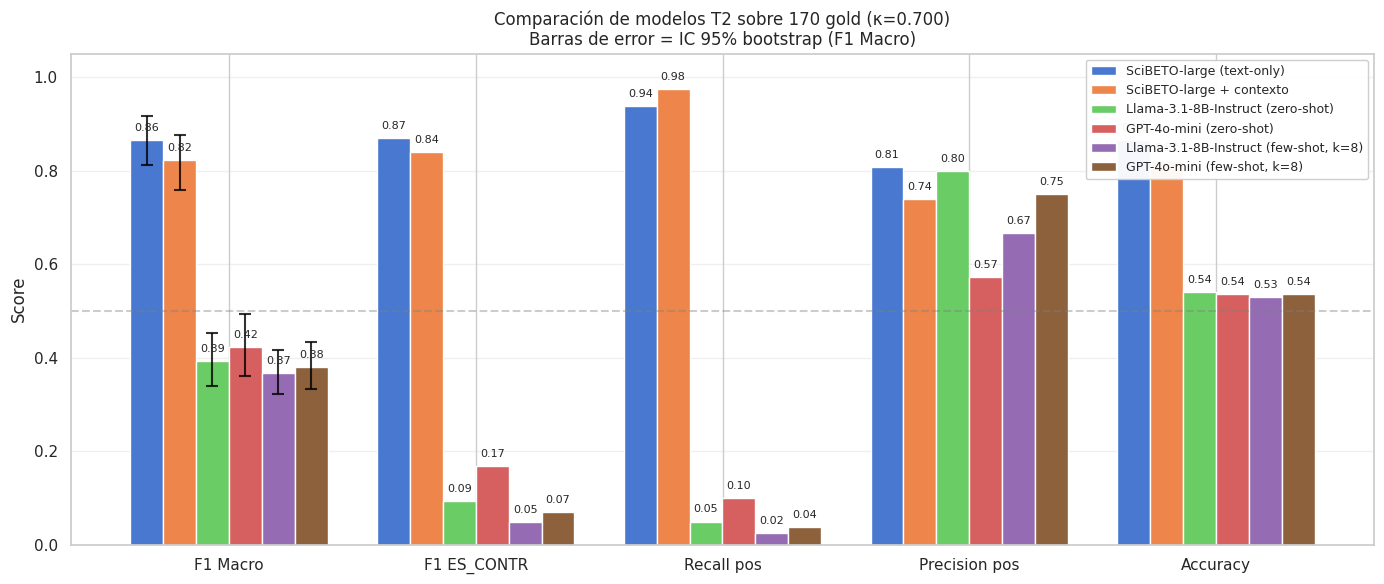

In [32]:
metrics_to_plot = ["f1_macro", "f1_positivos", "recall_pos", "precision_pos", "accuracy"]
metric_names    = ["F1 Macro", "F1 ES_CONTR", "Recall pos", "Precision pos", "Accuracy"]

model_keys = list(all_results.keys())
x = np.arange(len(metric_names))
width = 0.8 / len(model_keys)

fig, ax = plt.subplots(figsize=(14, 6))
palette = sns.color_palette("muted", len(model_keys))

for i, key in enumerate(model_keys):
    m = all_results[key]["metrics"]
    b = all_results[key]["bootstrap"]
    vals = [m.get(mm, np.nan) for mm in metrics_to_plot]
    bars = ax.bar(x + i*width, vals, width,
                  label=m["model"], color=palette[i], edgecolor="white")
    # CI 95% solo en F1 Macro (índice 0)
    ax.errorbar([x[0] + i*width], [m["f1_macro"]],
                yerr=[[m["f1_macro"] - b["ci_low"]], [b["ci_high"] - m["f1_macro"]]],
                fmt="none", ecolor="black", capsize=4, capthick=1.5, alpha=0.8)
    for bar, v in zip(bars, vals):
        if v is not None and not (isinstance(v, float) and np.isnan(v)):
            ax.text(bar.get_x()+bar.get_width()/2, v+0.015, f"{v:.2f}",
                    ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width*(len(model_keys)-1)/2)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title(f"Comparación de modelos T2 sobre 170 gold (κ={KAPPA:.3f})\nBarras de error = IC 95% bootstrap (F1 Macro)")
ax.legend(loc="upper right", fontsize=9, framealpha=0.95)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.4)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{MODEL_OUT_CTX}/g5_metrics_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

### Gráfica 6 — Confusion matrices side-by-side

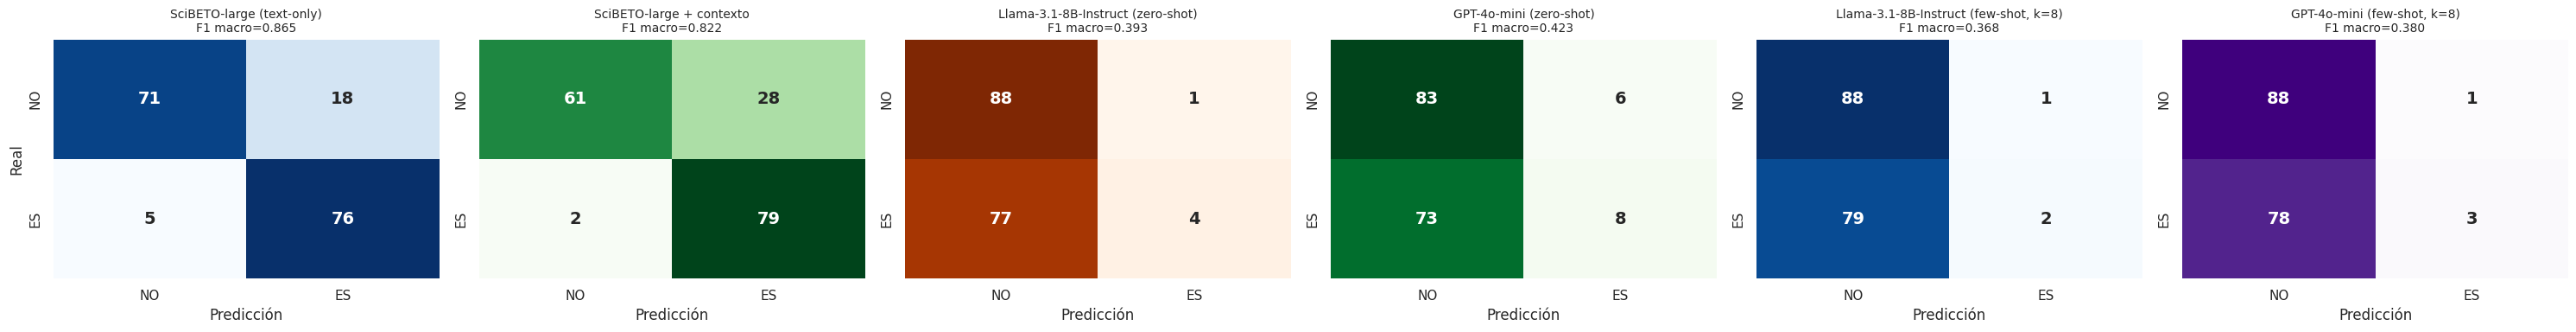

In [53]:
fig, axes = plt.subplots(1, len(all_results), figsize=(5*len(all_results), 4))
if len(all_results) == 1: axes = [axes]
cmaps = ["Blues", "Greens", "Oranges", "Greens", "Blues", "Purples"]

for ax, (key, res), cmap in zip(axes, all_results.items(), cmaps):
    cm = confusion_matrix(res["labels"], res["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=["NO","ES"], yticklabels=["NO","ES"], ax=ax,
                annot_kws={"size":14, "weight":"bold"}, cbar=False)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real" if ax is axes[0] else "")
    f1m = res["metrics"]["f1_macro"]
    ax.set_title(f"{res['metrics']['model']}\nF1 macro={f1m:.3f}", fontsize=10)
plt.tight_layout()
plt.savefig(f"{MODEL_OUT_CTX}/g6_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

### Gráfica 7 — F1 por sección retórica (heatmap)

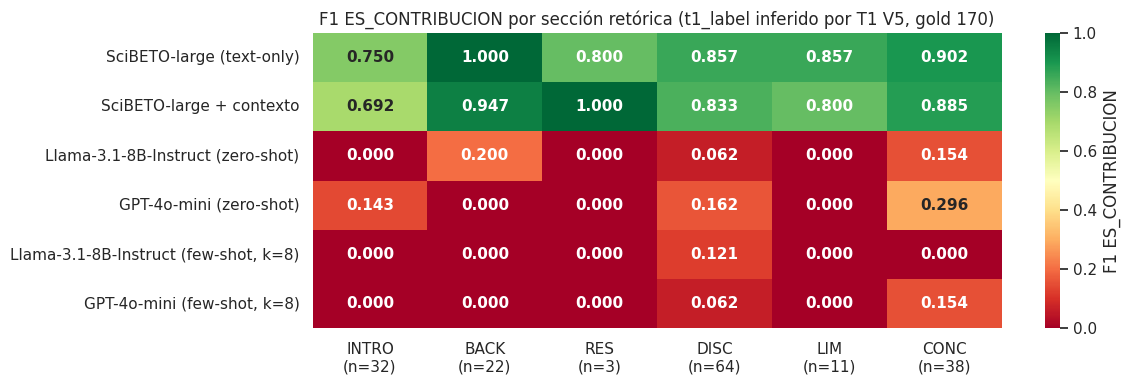

In [34]:
def f1_by_section(preds, labels, sections, min_samples=3):
    out = {}
    for sec in sorted(set(sections)):
        mask = sections == sec
        if mask.sum() < min_samples: continue
        f1 = f1_score(labels[mask], preds[mask], zero_division=0)
        out[sec] = {"f1": f1, "n_total": int(mask.sum()),
                    "n_pos": int((labels[mask]==1).sum())}
    return out

sections_170 = df_test_170["t1_label"].values
section_f1 = {k: f1_by_section(r["preds"], r["labels"], sections_170)
              for k, r in all_results.items()}

df_section = pd.DataFrame({
    res["metrics"]["model"]: {sec: d["f1"] for sec, d in section_f1[k].items()}
    for k, res in all_results.items()
}).T

T1_ORDER = ["INTRO","BACK","METH","RES","DISC","LIM","CONC"]
cols_present = [s for s in T1_ORDER if s in df_section.columns]
df_section = df_section[cols_present]
n_per_section = df_test_170["t1_label"].value_counts().reindex(cols_present)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(df_section, annot=True, fmt=".3f", cmap="RdYlGn",
            vmin=0, vmax=1, ax=ax, annot_kws={"size":11, "weight":"bold"},
            cbar_kws={"label":"F1 ES_CONTRIBUCION"})
ax.set_xticklabels([f"{c}\n(n={n_per_section.get(c,0)})" for c in cols_present], rotation=0)
ax.set_title(f"F1 ES_CONTRIBUCION por sección retórica (t1_label inferido por T1 V5, gold 170)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(f"{MODEL_OUT_CTX}/g7_f1_by_section.png", dpi=120, bbox_inches="tight")
plt.show()

### Gráfica 8 — Histograma de probabilidades por clase (SciBETOs)

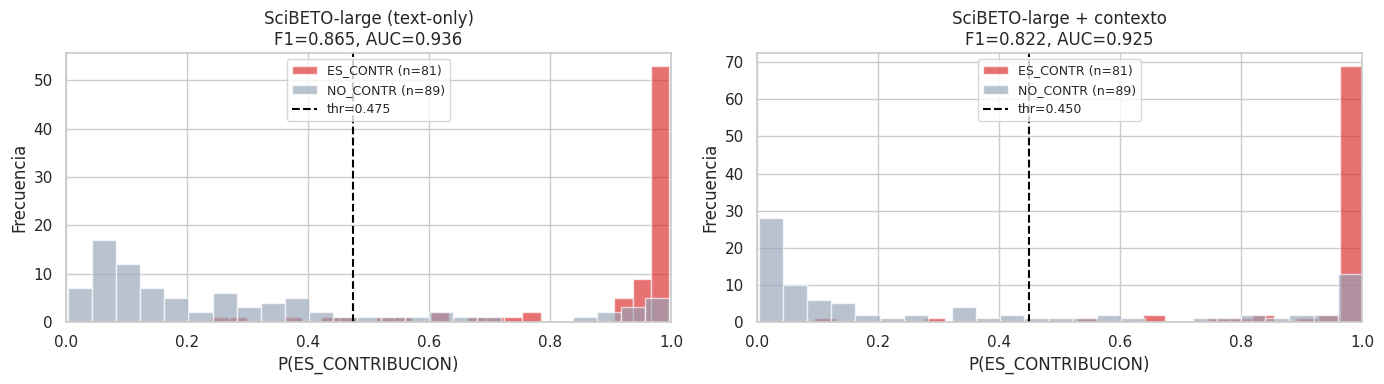

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
encoder_keys = [k for k in all_results.keys() if "probs" in all_results[k] and "scibeto" in k.lower()]

for ax, key in zip(axes, encoder_keys):
    res = all_results[key]
    probs = res["probs"]; labels = res["labels"]
    for cls, color, name in [(1, "#dc2626", "ES_CONTR"), (0, "#94a3b8", "NO_CONTR")]:
        ax.hist(probs[labels == cls], bins=25, alpha=0.65, color=color,
                edgecolor="white", label=f"{name} (n={(labels==cls).sum()})")
    ax.axvline(res["metrics"]["threshold"], color="black", linestyle="--",
               label=f"thr={res['metrics']['threshold']:.3f}")
    ax.set_xlabel("P(ES_CONTRIBUCION)")
    ax.set_ylabel("Frecuencia")
    ax.set_title(f"{res['metrics']['model']}\nF1={res['metrics']['f1_macro']:.3f}, AUC={res['metrics']['auc']:.3f}")
    ax.legend(loc="upper center", fontsize=9)
    ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(f"{MODEL_OUT_CTX}/g8_prob_histograms.png", dpi=120, bbox_inches="tight")
plt.show()

### Gráfica 9 — Curvas ROC y Precision-Recall (SciBETOs)

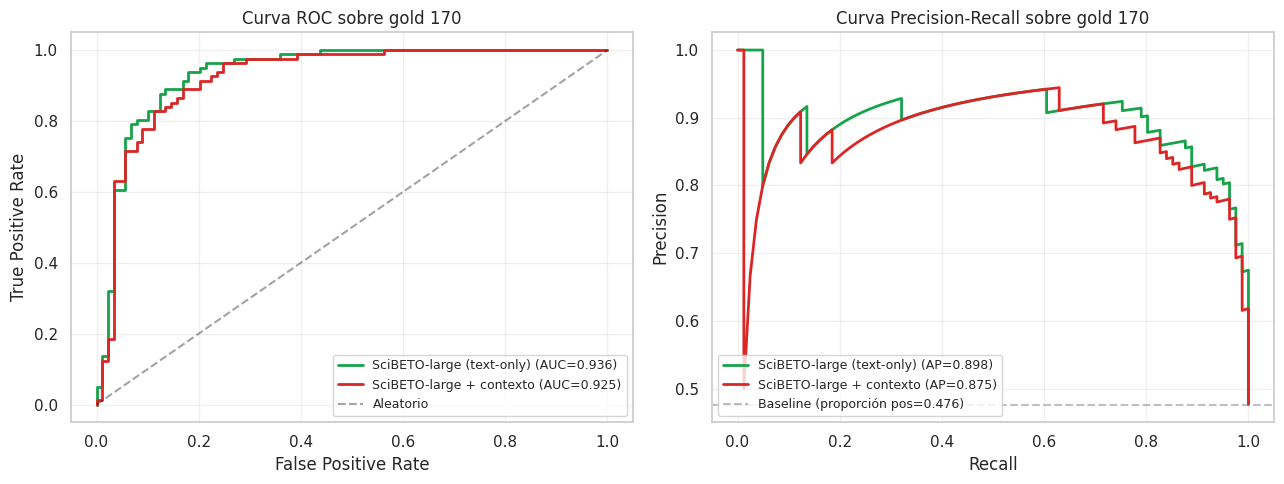

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
for key, color in zip(encoder_keys, ["#16a34a", "#dc2626"]):
    res = all_results[key]
    fpr, tpr, _ = roc_curve(res["labels"], res["probs"])
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f"{res['metrics']['model']} (AUC={res['metrics']['auc']:.3f})")
axes[0].plot([0,1], [0,1], "k--", alpha=0.4, label="Aleatorio")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Curva ROC sobre gold 170")
axes[0].legend(loc="lower right", fontsize=9); axes[0].grid(alpha=0.3)

# PR
n_pos = (labels_170 == 1).sum(); baseline_ap = n_pos / len(labels_170)
for key, color in zip(encoder_keys, ["#16a34a", "#dc2626"]):
    res = all_results[key]
    prec, rec, _ = precision_recall_curve(res["labels"], res["probs"])
    axes[1].plot(rec, prec, color=color, lw=2,
                 label=f"{res['metrics']['model']} (AP={res['metrics']['ap']:.3f})")
axes[1].axhline(baseline_ap, color="gray", linestyle="--", alpha=0.5,
                label=f"Baseline (proporción pos={baseline_ap:.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall sobre gold 170")
axes[1].legend(loc="lower left", fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{MODEL_OUT_CTX}/g9_roc_pr_curves.png", dpi=120, bbox_inches="tight")
plt.show()

### Gráfica 10 — Reliability diagram (calibración de probabilidades)

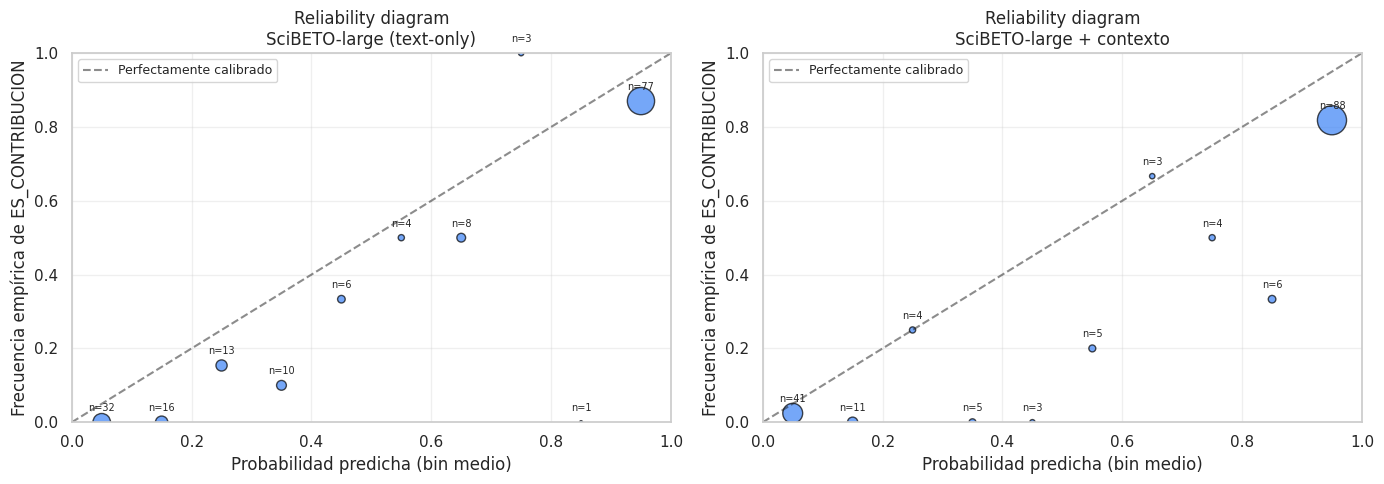

In [37]:
def reliability_data(probs, labels, n_bins=10):
    bins = np.linspace(0, 1, n_bins+1)
    bin_idx = np.digitize(probs, bins) - 1
    bin_idx = np.clip(bin_idx, 0, n_bins-1)
    bin_centers, bin_emp_pos, bin_counts = [], [], []
    for b in range(n_bins):
        mask = bin_idx == b
        if mask.sum() > 0:
            bin_centers.append((bins[b] + bins[b+1]) / 2)
            bin_emp_pos.append(labels[mask].mean())
            bin_counts.append(mask.sum())
    return np.array(bin_centers), np.array(bin_emp_pos), np.array(bin_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, key in zip(axes, encoder_keys):
    res = all_results[key]
    bc, ep, cnt = reliability_data(res["probs"], res["labels"])
    ax.plot([0,1], [0,1], "k--", alpha=0.5, label="Perfectamente calibrado")
    ax.scatter(bc, ep, s=cnt*5, alpha=0.7, color="#3b82f6", edgecolor="black")
    for x_, y_, c_ in zip(bc, ep, cnt):
        ax.text(x_, y_+0.03, f"n={c_}", ha="center", fontsize=7)
    ax.set_xlabel("Probabilidad predicha (bin medio)")
    ax.set_ylabel("Frecuencia empírica de ES_CONTRIBUCION")
    ax.set_title(f"Reliability diagram\n{res['metrics']['model']}")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(loc="upper left", fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{MODEL_OUT_CTX}/g10_reliability.png", dpi=120, bbox_inches="tight")
plt.show()

### Gráfica 11 — Boxplot de longitud por TP/FP/TN/FN

/tmp/ipykernel_39024/1154831944.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{c}\nn={n_cats.get(c,0)}" for c in order])
/tmp/ipykernel_39024/1154831944.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{c}\nn={n_cats.get(c,0)}" for c in order])
/tmp/ipykernel_39024/1154831944.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{c}\nn={n_cats.get(c,0)}" for c in order])
/tmp/ipykernel_39024/1154831944.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{c}\nn={n_cats.get(c,0)}" for c in order])
/tmp/ipykernel_39024/1154831944.py:21: UserWarning: set_ticklabe

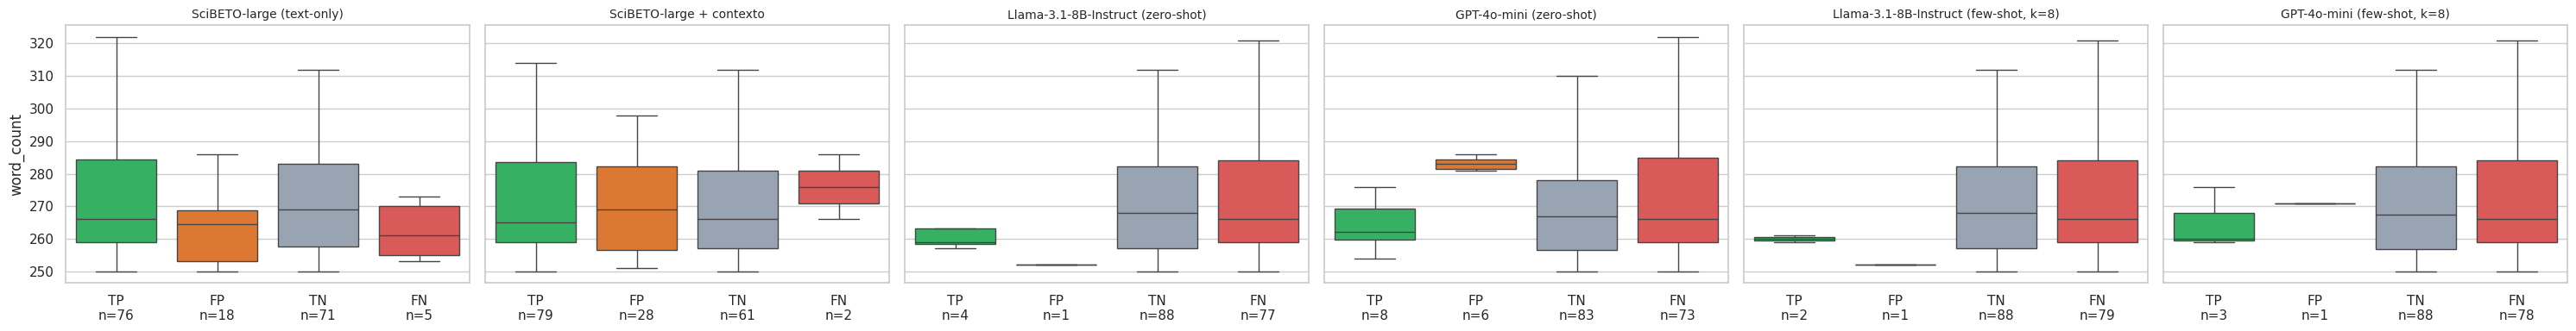

In [38]:
def categorize_errors(preds, labels):
    cats = np.empty(len(preds), dtype=object)
    cats[(preds==1) & (labels==1)] = "TP"
    cats[(preds==1) & (labels==0)] = "FP"
    cats[(preds==0) & (labels==0)] = "TN"
    cats[(preds==0) & (labels==1)] = "FN"
    return cats

fig, axes = plt.subplots(1, len(all_results), figsize=(5*len(all_results), 4), sharey=True)
if len(all_results) == 1: axes = [axes]
word_counts_170 = df_test_170["word_count"].values
palette_box = {"TP":"#22c55e", "FP":"#f97316", "TN":"#94a3b8", "FN":"#ef4444"}

for ax, (key, res) in zip(axes, all_results.items()):
    cats = categorize_errors(res["preds"], res["labels"])
    df_box = pd.DataFrame({"cat":cats, "wc":word_counts_170})
    order = ["TP","FP","TN","FN"]
    sns.boxplot(data=df_box, x="cat", y="wc", ax=ax, order=order,
                hue="cat", palette=palette_box, legend=False, showfliers=False)
    n_cats = df_box["cat"].value_counts()
    ax.set_xticklabels([f"{c}\nn={n_cats.get(c,0)}" for c in order])
    ax.set_title(res["metrics"]["model"], fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("word_count" if ax is axes[0] else "")
plt.tight_layout()
plt.savefig(f"{MODEL_OUT_CTX}/g11_length_by_error.png", dpi=120, bbox_inches="tight")
plt.show()

### Gráfica 12 — Distribución bootstrap de F1 macro

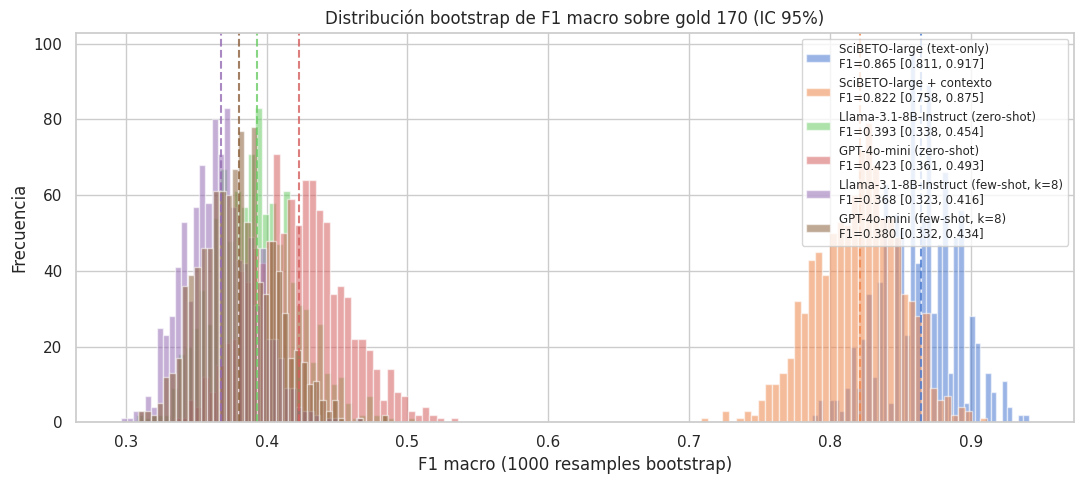

In [39]:
fig, ax = plt.subplots(figsize=(11, 5))
palette_b = sns.color_palette("muted", len(all_results))
for (key, res), color in zip(all_results.items(), palette_b):
    boot = res["bootstrap"]
    ax.hist(boot["all_f1s"], bins=40, alpha=0.55, color=color,
            label=f"{res['metrics']['model']}\nF1={res['metrics']['f1_macro']:.3f} [{boot['ci_low']:.3f}, {boot['ci_high']:.3f}]",
            edgecolor="white")
    ax.axvline(res["metrics"]["f1_macro"], color=color, linestyle="--", alpha=0.8)
ax.set_xlabel("F1 macro (1000 resamples bootstrap)")
ax.set_ylabel("Frecuencia")
ax.set_title(f"Distribución bootstrap de F1 macro sobre gold 170 (IC 95%)")
ax.legend(loc="upper right", fontsize=8.5)
plt.tight_layout()
plt.savefig(f"{MODEL_OUT_CTX}/g12_bootstrap_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

### Gráfica 13 — Threshold sweep para los SciBETOs (calibración demostrador)

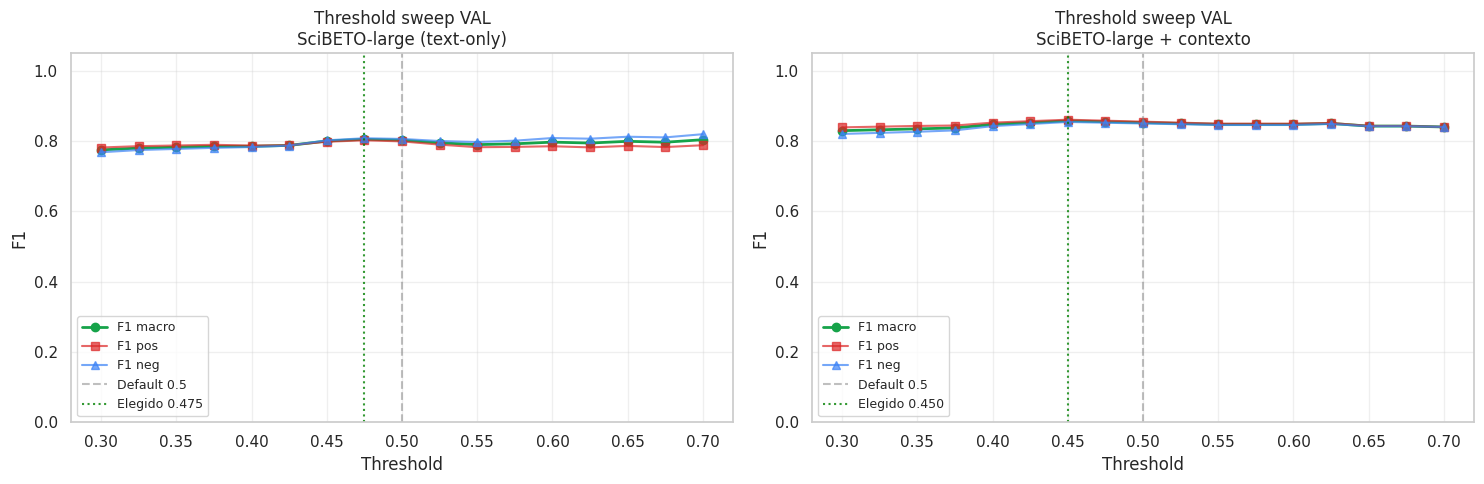

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, key in zip(axes, encoder_keys):
    res = all_results[key]
    sw = res["sweep"]
    ax.plot(sw["threshold"], sw["f1_macro"], "o-", color="#16a34a", lw=2, label="F1 macro")
    ax.plot(sw["threshold"], sw["f1_pos"], "s-", color="#dc2626", alpha=0.7, label="F1 pos")
    ax.plot(sw["threshold"], sw["f1_neg"], "^-", color="#3b82f6", alpha=0.7, label="F1 neg")
    chosen_thr = res["metrics"]["threshold"]
    ax.axvline(0.5, color="gray", linestyle="--", alpha=0.5, label="Default 0.5")
    ax.axvline(chosen_thr, color="green", linestyle=":", alpha=0.8, label=f"Elegido {chosen_thr:.3f}")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("F1")
    ax.set_title(f"Threshold sweep VAL\n{res['metrics']['model']}")
    ax.legend(loc="best", fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(f"{MODEL_OUT_CTX}/g13_threshold_sweep.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 15. Análisis cualitativo de los 30 ambiguos

Estos fragmentos NO tienen consenso entre anotadores, por lo que NO se incluyen
en métricas. Su análisis revela:
1. **Casos donde TODOS los modelos coinciden**: pueden ser señal de que la
   ambigüedad es entre los anotadores humanos (uno conservador, otro laxo),
   pero el patrón es claro.
2. **Casos donde los modelos discrepan entre sí**: son los genuinamente
   difíciles para humanos Y máquinas.

In [41]:
# Construir matriz de predicciones de los 4 modelos sobre los 30
# (Llama y GPT ya predijeron sobre df_test_30; falta SciBETOs)

# Predecir SciBETOs sobre 30 (necesita re-cargar... pero los modelos están borrados.
# Reabrimos desde Drive)
from transformers import AutoTokenizer, AutoModelForSequenceClassification

print("Re-cargando SciBETOs desde Drive para predecir sobre los 30 ambiguos...")

# Baseline
tok_base_r = AutoTokenizer.from_pretrained(MODEL_OUT_BASE)
model_base_r = AutoModelForSequenceClassification.from_pretrained(MODEL_OUT_BASE)
model_base_r.eval()
if torch.cuda.is_available(): model_base_r = model_base_r.cuda().half()

@torch.no_grad()
def predict_encoder(df_, tokenizer, model, dataset_cls, batch_size=8):
    ds = dataset_cls(df_.assign(a1_class=0), tokenizer, ENCODER_CONFIG["max_length"])
    probs_all = []
    for i in range(0, len(ds), batch_size):
        batch = [ds[j] for j in range(i, min(i+batch_size, len(ds)))]
        input_ids = torch.stack([b["input_ids"] for b in batch])
        attn = torch.stack([b["attention_mask"] for b in batch])
        if torch.cuda.is_available():
            input_ids, attn = input_ids.cuda(), attn.cuda()
        logits = model(input_ids=input_ids, attention_mask=attn).logits
        probs = torch.softmax(logits.float(), dim=-1).cpu().numpy()[:, 1]
        probs_all.append(probs)
    return np.concatenate(probs_all)

probs_base_30 = predict_encoder(df_test_30, tok_base_r, model_base_r, PlainTextDataset)
preds_base_30 = (probs_base_30 >= thr_base).astype(int)
del model_base_r, tok_base_r
torch.cuda.empty_cache()

# Ctx
tok_ctx_r = AutoTokenizer.from_pretrained(MODEL_OUT_CTX)
model_ctx_r = AutoModelForSequenceClassification.from_pretrained(MODEL_OUT_CTX)
model_ctx_r.eval()
if torch.cuda.is_available(): model_ctx_r = model_ctx_r.cuda().half()

probs_ctx_30 = predict_encoder(df_test_30, tok_ctx_r, model_ctx_r, ContextDataset)
preds_ctx_30 = (probs_ctx_30 >= thr_ctx).astype(int)
del model_ctx_r, tok_ctx_r
torch.cuda.empty_cache()

# Construir DataFrame con todas las predicciones
df_30_preds = pd.DataFrame({
    "id":          df_test_30["id"].values,
    "t1_label":    df_test_30["t1_label"].values,
    "word_count":  df_test_30["word_count"].values,
    "SciBETO-base":        preds_base_30,
    "SciBETO-ctx":         preds_ctx_30,
    "Llama-3.1-8b-zero":   llama_preds_30,
    "Llama-3.1-8b-fs8":    llama_fs_preds_30,
    "GPT-4o-mini-zero":    gpt_preds_30,
    "GPT-4o-mini-fs8":     gpt_fs_preds_30,
})
MODEL_COLS_30 = ["SciBETO-base","SciBETO-ctx","Llama-3.1-8b-zero","Llama-3.1-8b-fs8","GPT-4o-mini-zero","GPT-4o-mini-fs8"]
df_30_preds["n_models_say_yes"] = df_30_preds[MODEL_COLS_30].sum(axis=1)

print(f"\n  ✓ Predicciones de 6 modelos × 30 ambiguos calculadas")
print(f"  Modelos que coinciden en 'SI' por sample (0-6):")
print(df_30_preds["n_models_say_yes"].value_counts().sort_index().to_string())

Re-cargando SciBETOs desde Drive para predecir sobre los 30 ambiguos...


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]


  ✓ Predicciones de 6 modelos × 30 ambiguos calculadas
  Modelos que coinciden en 'SI' por sample (0-6):
n_models_say_yes
0    12
1     3
2    12
3     2
4     1


### Gráfica 14 — Heatmap de predicciones sobre los 30 ambiguos

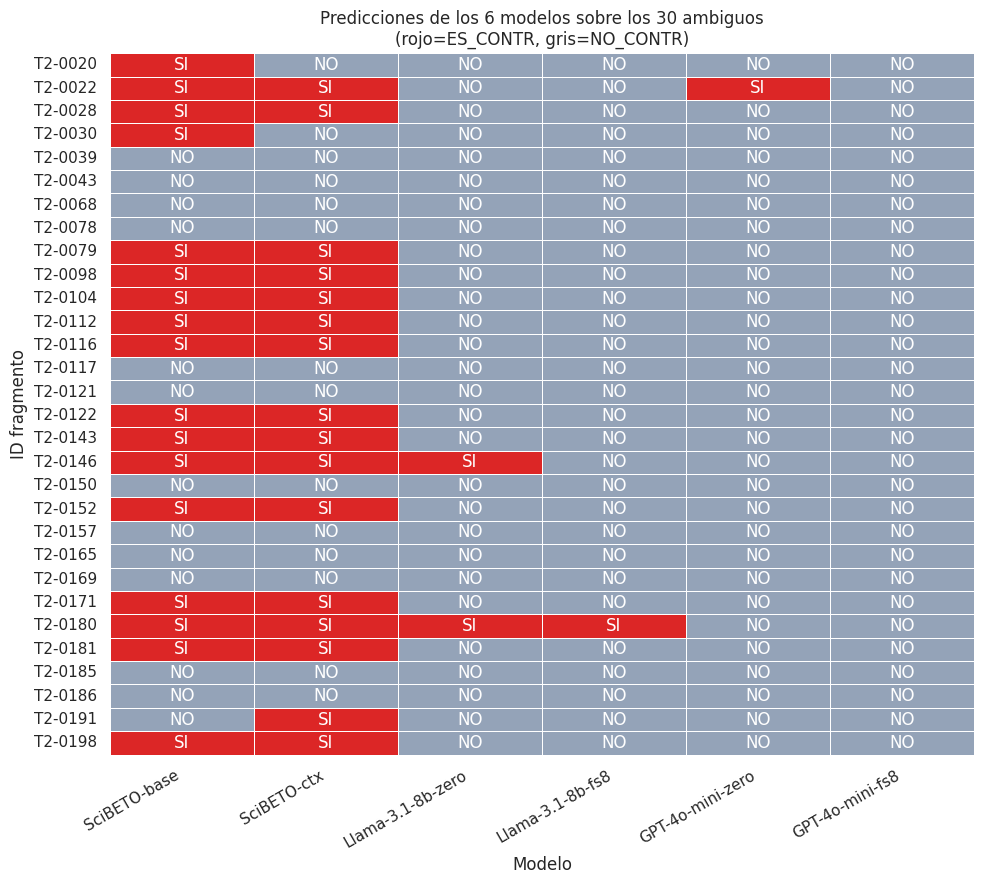

In [42]:
fig, ax = plt.subplots(figsize=(10, 9))
heatmap_data = df_30_preds[MODEL_COLS_30].copy()
heatmap_data.index = df_30_preds["id"]
sns.heatmap(heatmap_data, cmap=["#94a3b8","#dc2626"], cbar=False,
            linewidths=0.4, linecolor="white", ax=ax,
            annot=heatmap_data.replace({1:"SI", 0:"NO"}).values,
            fmt="")
ax.set_title("Predicciones de los 6 modelos sobre los 30 ambiguos\n(rojo=ES_CONTR, gris=NO_CONTR)")
ax.set_xlabel("Modelo"); ax.set_ylabel("ID fragmento")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{MODEL_OUT_CTX}/g14_ambiguous_predictions.png", dpi=120, bbox_inches="tight")
plt.show()

### 15.1 Ejemplos cualitativos seleccionados

In [43]:
# Casos donde TODOS coinciden en SI o NO
all_yes = df_30_preds[df_30_preds["n_models_say_yes"] == 6]
all_no  = df_30_preds[df_30_preds["n_models_say_yes"] == 0]
mixed   = df_30_preds[(df_30_preds["n_models_say_yes"] >= 1) & (df_30_preds["n_models_say_yes"] <= 5)]

print(f"\n{'='*72}")
print(f"  ANÁLISIS DE LOS 30 AMBIGUOS (predicciones de 6 modelos)")
print(f"{'='*72}")
print(f"\n  Todos coinciden en SI ({len(all_yes)}):  {all_yes['id'].tolist()}")
print(f"  Todos coinciden en NO ({len(all_no)}):   {all_no['id'].tolist()}")
print(f"  Modelos discrepan ({len(mixed)}):        {mixed['id'].tolist()}")

print(f"\n  ── Ejemplos de las 3 categorías ──")
for category, df_subset, n_show in [
    ("TODOS coinciden en SI",  all_yes, min(2, len(all_yes))),
    ("TODOS coinciden en NO",  all_no,  min(2, len(all_no))),
    ("Modelos DISCREPAN",      mixed,   min(3, len(mixed))),
]:
    print(f"\n  ▸ {category}:")
    for _, row in df_subset.head(n_show).iterrows():
        text_orig = df_test_30[df_test_30["id"] == row["id"]]["text"].iloc[0]
        text_show = str(text_orig)[:250]
        preds_str = " · ".join([f"{m}={'SI' if row[m]==1 else 'NO'}"
                                for m in MODEL_COLS_30])
        print(f"\n    [{row['id']}] t1={row['t1_label']:5s} n_yes={int(row['n_models_say_yes'])}/6")
        print(f"       {preds_str}")
        print(f"       {text_show}...")


  ANÁLISIS DE LOS 30 AMBIGUOS (predicciones de 6 modelos)

  Todos coinciden en SI (0):  []
  Todos coinciden en NO (12):   ['T2-0039', 'T2-0043', 'T2-0068', 'T2-0078', 'T2-0117', 'T2-0121', 'T2-0150', 'T2-0157', 'T2-0165', 'T2-0169', 'T2-0185', 'T2-0186']
  Modelos discrepan (18):        ['T2-0020', 'T2-0022', 'T2-0028', 'T2-0030', 'T2-0079', 'T2-0098', 'T2-0104', 'T2-0112', 'T2-0116', 'T2-0122', 'T2-0143', 'T2-0146', 'T2-0152', 'T2-0171', 'T2-0180', 'T2-0181', 'T2-0191', 'T2-0198']

  ── Ejemplos de las 3 categorías ──

  ▸ TODOS coinciden en SI:

  ▸ TODOS coinciden en NO:

    [T2-0039] t1=INTRO n_yes=0/6
       SciBETO-base=NO · SciBETO-ctx=NO · Llama-3.1-8b-zero=NO · Llama-3.1-8b-fs8=NO · GPT-4o-mini-zero=NO · GPT-4o-mini-fs8=NO
       1 Andalucía: V. Gallardo; Aragón: B. Adiego; Asturias: I. Huertas; Baleares: A. Magistris, A. Galmés; Canarias: A. García; Cantabria: L. J. Viloria; Castilla-La Mancha: G. Gutiérrez, B. Puente; Castilla y León: M. J. Rodríguez; Cataluña: N. Torner

---
## 16. Validación de leakage + ablations (sobre 170 gold)

Mismos chequeos que en v2 pero **sobre el test correcto (170 gold)**.

In [44]:
# CHEQUEO 1 — Solapamiento de documentos
print("="*72)
print("  CHEQUEO 1 — Solapamiento de documentos train ↔ test")
print("="*72)

DOC_ID_CANDIDATES = ["doc_id","paper_id","article_id","document_id","source","source_id","filename","path","url"]
def find_doc_id_col(df):
    for c in DOC_ID_CANDIDATES:
        if c in df.columns: return c
    return None

doc_col_train = find_doc_id_col(df_train)
doc_col_test  = find_doc_id_col(df_test_170)
print(f"  Columnas detectadas: train={doc_col_train} | test_170={doc_col_test}")

if doc_col_train and doc_col_test:
    train_docs = set(df_train[doc_col_train].dropna().astype(str).unique())
    test_docs  = set(df_test_170[doc_col_test].dropna().astype(str).unique())
    overlap = train_docs & test_docs
    print(f"  |docs train|={len(train_docs)} | |docs test_170|={len(test_docs)}")
    print(f"  Solape: {len(overlap)} documentos compartidos")
    verdict_doc = "🟢 OK — particiones disjuntas" if len(overlap) == 0 else f"🔴 CRÍTICO — {len(overlap)} docs solapan"
else:
    verdict_doc = "🟡 ATENCIÓN — sin columna de doc_id, verificar manualmente"
print(f"\n  Veredicto: {verdict_doc}")

  CHEQUEO 1 — Solapamiento de documentos train ↔ test
  Columnas detectadas: train=doc_id | test_170=None

  Veredicto: 🟡 ATENCIÓN — sin columna de doc_id, verificar manualmente


In [45]:
# CHEQUEO 2 — Distribución T1 × T2 en gold 170
print("\n" + "="*72)
print("  CHEQUEO 2 — Distribución T1 × T2 en gold 170")
print("="*72)

cross = df_test_170.groupby(["t1_label","a1_label"]).size().unstack(fill_value=0)
cross = cross.reindex([t for t in T1_ORDER if t in cross.index])
if "ES_CONTRIBUCION" not in cross.columns: cross["ES_CONTRIBUCION"] = 0
if "NO_ES_CONTRIBUCION" not in cross.columns: cross["NO_ES_CONTRIBUCION"] = 0
cross["total"] = cross.sum(axis=1)
cross["pct_pos"] = (cross["ES_CONTRIBUCION"] / cross["total"].replace(0,1) * 100).round(1)
print(cross.to_string())

shortcuts = cross[((cross["pct_pos"] >= 80) | (cross["pct_pos"] <= 20)) & (cross["total"] >= 5)]
print(f"\n  Secciones con atajo trivial (>=80% o <=20%, min 5 muestras): {list(shortcuts.index)}")
verdict_t1t2 = "🟢 OK — sin atajos triviales" if len(shortcuts) == 0 else f"🟡 ATENCIÓN — {list(shortcuts.index)}"
print(f"  Veredicto: {verdict_t1t2}")


  CHEQUEO 2 — Distribución T1 × T2 en gold 170
a1_label  ES_CONTRIBUCION  NO_ES_CONTRIBUCION  total  pct_pos
t1_label                                                     
INTRO                  10                  22     32     31.2
BACK                    9                  13     22     40.9
RES                     2                   1      3     66.7
DISC                   31                  33     64     48.4
LIM                     6                   5     11     54.5
CONC                   23                  15     38     60.5

  Secciones con atajo trivial (>=80% o <=20%, min 5 muestras): []
  Veredicto: 🟢 OK — sin atajos triviales


In [46]:
# CHEQUEO 3 — Ablation A: prefijo aleatorio sobre 170 (solo aplica al ctx)
print("\n" + "="*72)
print("  CHEQUEO 3 — Ablation A: prefijo aleatorio (modelo ctx)")
print("="*72)

# Re-cargar el modelo ctx
tok_ctx_r2 = AutoTokenizer.from_pretrained(MODEL_OUT_CTX)
model_ctx_r2 = AutoModelForSequenceClassification.from_pretrained(MODEL_OUT_CTX)
model_ctx_r2.eval()
if torch.cuda.is_available(): model_ctx_r2 = model_ctx_r2.cuda().half()

T1_LABELS_VALID = ["INTRO","BACK","METH","RES","DISC","LIM","CONC"]
rng = np.random.default_rng(seed=42)
df_test_random = df_test_170.copy().reset_index(drop=True)
df_test_random["t1_label"]     = rng.choice(T1_LABELS_VALID, size=len(df_test_random))
df_test_random["relative_pos"] = rng.uniform(0, 1, size=len(df_test_random))

probs_random = predict_encoder(df_test_random, tok_ctx_r2, model_ctx_r2, ContextDataset)
preds_random = (probs_random >= thr_ctx).astype(int)
f1m_random = f1_score(labels_170, preds_random, average="macro", zero_division=0)
f1p_random = f1_score(labels_170, preds_random, pos_label=1, zero_division=0)

drop_random = res_ctx["metrics"]["f1_macro"] - f1m_random
print(f"  F1 macro normal:           {res_ctx['metrics']['f1_macro']:.4f}")
print(f"  F1 macro prefijo aleatorio:{f1m_random:.4f}")
print(f"  Drop por randomización:    {drop_random:+.4f}")

# Umbrales corregidos (v3 los tenía muy laxos):
#   drop < 0.05  → 🟢 OK (modelo no usa prefijo, o lo usa marginalmente)
#   0.05 ≤ drop < 0.15 → 🟢 SALUDABLE (combinación texto+prefijo equilibrada)
#   0.15 ≤ drop < 0.25 → 🟡 ATENCIÓN (modelo apoya decisiones en prefijo)
#   drop ≥ 0.25  → 🔴 CRÍTICO (modelo aprendió atajos t1_label/pos → clase)
if drop_random < 0.05:
    verdict_random = f"🟢 OK — el modelo NO depende del prefijo (drop={drop_random:.3f})"
elif drop_random < 0.15:
    verdict_random = f"🟢 SALUDABLE — modelo combina texto + prefijo (drop={drop_random:.3f})"
elif drop_random < 0.25:
    verdict_random = f"🟡 ATENCIÓN — el modelo apoya decisiones en el prefijo (drop={drop_random:.3f})"
else:
    verdict_random = (f"🔴 CRÍTICO — modelo aprendió atajo {{t1_label/pos → clase}} "
                      f"(drop={drop_random:.3f}). El F1 reportado depende de que T1 "
                      f"prediga correctamente. Si T1 falla, T2 falla.")
print(f"  Veredicto: {verdict_random}")


  CHEQUEO 3 — Ablation A: prefijo aleatorio (modelo ctx)


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

  F1 macro normal:           0.8215
  F1 macro prefijo aleatorio:0.5385
  Drop por randomización:    +0.2830
  Veredicto: 🔴 CRÍTICO — modelo aprendió atajo {t1_label/pos → clase} (drop=0.283). El F1 reportado depende de que T1 prediga correctamente. Si T1 falla, T2 falla.


In [47]:
# CHEQUEO 4 — Ablation B: solo prefijo, texto vacío
print("\n" + "="*72)
print("  CHEQUEO 4 — Ablation B: solo prefijo (texto vacío)")
print("="*72)

df_test_empty = df_test_170.copy().reset_index(drop=True)
df_test_empty["text"] = ""
probs_empty = predict_encoder(df_test_empty, tok_ctx_r2, model_ctx_r2, ContextDataset)
preds_empty = (probs_empty >= thr_ctx).astype(int)
f1m_empty = f1_score(labels_170, preds_empty, average="macro", zero_division=0)

print(f"  F1 macro normal:        {res_ctx['metrics']['f1_macro']:.4f}")
print(f"  F1 macro solo prefijo:  {f1m_empty:.4f}")

if f1m_empty < 0.55:
    verdict_empty = "🟢 OK — sin texto, F1 ≈ aleatorio. El modelo NECESITA texto"
elif f1m_empty < 0.70:
    verdict_empty = f"🟡 ATENCIÓN — F1={f1m_empty:.3f} sin texto (prefijo aporta señal pero no toda)"
else:
    verdict_empty = f"🔴 CRÍTICO — F1={f1m_empty:.3f} solo con prefijo. El modelo NO usa texto"
print(f"  Veredicto: {verdict_empty}")

# Tabla de ablations
ablation_table = pd.DataFrame([
    {"Variante":"Prefijo real + texto real",  "F1 macro":res_ctx["metrics"]["f1_macro"]},
    {"Variante":"Prefijo aleatorio + texto",  "F1 macro":f1m_random},
    {"Variante":"Prefijo real + texto vacío", "F1 macro":f1m_empty},
])
print(f"\n  Tabla de ablations:\n{ablation_table.round(4).to_string(index=False)}")

del model_ctx_r2, tok_ctx_r2
torch.cuda.empty_cache()


  CHEQUEO 4 — Ablation B: solo prefijo (texto vacío)
  F1 macro normal:        0.8215
  F1 macro solo prefijo:  0.3227
  Veredicto: 🟢 OK — sin texto, F1 ≈ aleatorio. El modelo NECESITA texto

  Tabla de ablations:
                  Variante  F1 macro
 Prefijo real + texto real    0.8215
 Prefijo aleatorio + texto    0.5385
Prefijo real + texto vacío    0.3227


---
## 17. Análisis de costo y latencia (proyección a producción)

In [48]:
rows = []
for key, res in all_results.items():
    m = res["metrics"]
    rows.append({
        "Modelo":           m["model"],
        "F1 Macro":         round(m["f1_macro"], 3),
        "Latencia/sample":  f"{m.get('avg_latency_sec', 0):.2f}s",
        "Total (170)":      f"{m.get('total_time_sec', 0):.0f}s",
        "Costo USD (170)":  f"${m.get('cost_usd', 0):.4f}",
        "Despliegue":       "GPU local" if "GPT" not in m["model"] else "API externa",
        "Privacidad":       "Datos en server" if "GPT" not in m["model"] else "Datos salen al proveedor",
    })
print("\n" + "="*100)
print("  Trade-offs operacionales — defensa del demo")
print("="*100)
print(pd.DataFrame(rows).to_string(index=False))

print("\n  💡 Proyección a 1000 fragmentos:")
for key, res in all_results.items():
    m = res["metrics"]
    cost_1k = m.get("cost_usd", 0) / len(df_test_170) * 1000 if m.get("cost_usd") else 0
    time_1k = m.get("avg_latency_sec", 0) * 1000
    print(f"    {m['model']:45s} → {time_1k/60:5.1f} min  ·  ${cost_1k:.3f} USD")


  Trade-offs operacionales — defensa del demo
                               Modelo  F1 Macro Latencia/sample Total (170) Costo USD (170)  Despliegue               Privacidad
            SciBETO-large (text-only)     0.865           0.00s          0s         $0.0000   GPU local          Datos en server
             SciBETO-large + contexto     0.822           0.00s          0s         $0.0000   GPU local          Datos en server
    Llama-3.1-8B-Instruct (zero-shot)     0.393           0.24s         42s         $0.0000   GPU local          Datos en server
              GPT-4o-mini (zero-shot)     0.423           0.57s         97s         $0.0150 API externa Datos salen al proveedor
Llama-3.1-8B-Instruct (few-shot, k=8)     0.368           0.31s         54s         $0.0000   GPU local          Datos en server
          GPT-4o-mini (few-shot, k=8)     0.380           0.51s         87s         $0.0386 API externa Datos salen al proveedor

  💡 Proyección a 1000 fragmentos:
    SciBETO-lar

---
## 18. Reporte final

In [49]:
print("\n" + "═"*78)
print("  REPORTE FINAL — TAREA 2 v5")
print("  Test oficial: 170 con consenso interanotador (κ Cohen = 0.6995)")
print("═"*78)

print(f"\nDataset:")
print(f"  Train (silver) : {len(df_train):,} fragmentos")
print(f"  Val   (silver) : {len(df_val):,}")
print(f"  Test  (gold)   : {len(df_test_170)} con consenso · {len(df_test_30)} ambiguos (no en métricas)")

print(f"\nResultados (ordenados por F1 macro):")
ranked = sorted(all_results.items(), key=lambda kv: kv[1]["metrics"]["f1_macro"], reverse=True)
for rank, (key, res) in enumerate(ranked, 1):
    m, b = res["metrics"], res["bootstrap"]
    print(f"\n  #{rank} {m['model']}")
    print(f"      F1 macro      : {m['f1_macro']:.4f}  [IC 95%: {b['ci_low']:.4f}-{b['ci_high']:.4f}]")
    print(f"      F1 ES_CONTR   : {m['f1_positivos']:.4f}")
    print(f"      Precision pos : {m['precision_pos']:.4f}")
    print(f"      Recall pos    : {m['recall_pos']:.4f}")
    print(f"      Accuracy      : {m['accuracy']:.4f}")
    if not np.isnan(m.get("auc", float("nan"))):
        print(f"      AUC           : {m['auc']:.4f}")

# ── Δ ctx vs baseline (A5 del PDF) ───────────────────────────────────────────
delta_ctx = res_ctx["metrics"]["f1_macro"] - res_base["metrics"]["f1_macro"]
print(f"\n{'═'*78}")
print(f"  HALLAZGO PRINCIPAL — Efecto del contexto retórico (A5)")
print(f"{'═'*78}")
print(f"   F1 baseline text-only : {res_base['metrics']['f1_macro']:.4f}")
print(f"   F1 con prefijo ctx    : {res_ctx['metrics']['f1_macro']:.4f}")
print(f"   Δ                     : {delta_ctx:+.4f}")
print()
if delta_ctx > 0.02:
    print("   → CONTEXTO AYUDA. Usar el modelo ctx en producción.")
elif delta_ctx < -0.02:
    print("   → CONTEXTO DAÑA (hallazgo negativo).")
    print("     Reportamos ambos modelos como contribución dual:")
    print("       • scibert-es-t2 (text-only) — recomendado por mejor F1")
    print("       • scibert-es-t2-ctx — cumple requerimiento A5 + reporta ablación negativa")
    print("     El ablation A revela que ctx aprende atajos {t1_label, pos} → clase.")
else:
    print("   → CONTEXTO NEUTRO (|Δ| < 0.02). Reportar ambos sin preferencia clara.")

# ── Δ few-shot vs zero-shot para LLMs ────────────────────────────────────────
print(f"\n{'═'*78}")
print(f"  EFECTO DEL FEW-SHOT EN LLMs (8 ejemplos: 4 positivos + 4 negativos)")
print(f"{'═'*78}")
for base_key, fs_key, model_name in [
    ("llama-3.1-8b", "llama-3.1-8b-fs8", "Llama 3.1 8B"),
    ("gpt-4o-mini",  "gpt-4o-mini-fs8",  "GPT-4o-mini"),
]:
    f1_zero = all_results[base_key]["metrics"]["f1_macro"]
    f1_fs   = all_results[fs_key]["metrics"]["f1_macro"]
    recall_zero = all_results[base_key]["metrics"]["recall_pos"]
    recall_fs   = all_results[fs_key]["metrics"]["recall_pos"]
    print(f"\n   {model_name}:")
    print(f"      zero-shot F1 macro = {f1_zero:.4f} | recall pos = {recall_zero:.4f}")
    print(f"      few-shot  F1 macro = {f1_fs:.4f} | recall pos = {recall_fs:.4f}")
    print(f"      Δ F1 macro = {f1_fs - f1_zero:+.4f}")


══════════════════════════════════════════════════════════════════════════════
  REPORTE FINAL — TAREA 2 v5
  Test oficial: 170 con consenso interanotador (κ Cohen = 0.6995)
══════════════════════════════════════════════════════════════════════════════

Dataset:
  Train (silver) : 1,600 fragmentos
  Val   (silver) : 400
  Test  (gold)   : 170 con consenso · 30 ambiguos (no en métricas)

Resultados (ordenados por F1 macro):

  #1 SciBETO-large (text-only)
      F1 macro      : 0.8646  [IC 95%: 0.8113-0.9172]
      F1 ES_CONTR   : 0.8686
      Precision pos : 0.8085
      Recall pos    : 0.9383
      Accuracy      : 0.8647
      AUC           : 0.9363

  #2 SciBETO-large + contexto
      F1 macro      : 0.8215  [IC 95%: 0.7581-0.8752]
      F1 ES_CONTR   : 0.8404
      Precision pos : 0.7383
      Recall pos    : 0.9753
      Accuracy      : 0.8235
      AUC           : 0.9250

  #3 GPT-4o-mini (zero-shot)
      F1 macro      : 0.4230  [IC 95%: 0.3613-0.4928]
      F1 ES_CONTR   : 0.168

### Gráfica 15 — Zero-shot vs few-shot en LLMs

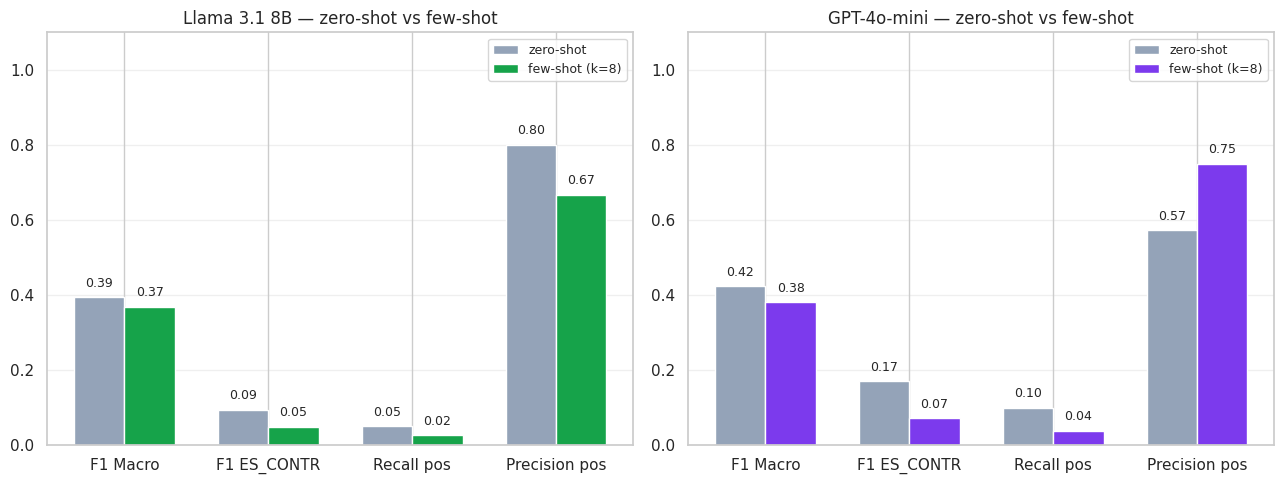

In [50]:
# Comparación visual del impacto del few-shot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metrics_to_plot = ["f1_macro", "f1_positivos", "recall_pos", "precision_pos"]
metric_names    = ["F1 Macro", "F1 ES_CONTR", "Recall pos", "Precision pos"]

# Llama
ax = axes[0]
x = np.arange(len(metric_names))
width = 0.35
vals_zero = [all_results["llama-3.1-8b"]["metrics"][m] for m in metrics_to_plot]
vals_fs   = [all_results["llama-3.1-8b-fs8"]["metrics"][m] for m in metrics_to_plot]
bars1 = ax.bar(x - width/2, vals_zero, width, label="zero-shot",  color="#94a3b8", edgecolor="white")
bars2 = ax.bar(x + width/2, vals_fs,   width, label="few-shot (k=8)", color="#16a34a", edgecolor="white")
for bar, v in zip(list(bars1)+list(bars2), vals_zero + vals_fs):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.02, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.1); ax.set_title("Llama 3.1 8B — zero-shot vs few-shot")
ax.legend(loc="upper right", fontsize=9); ax.grid(axis="y", alpha=0.3)

# GPT
ax = axes[1]
vals_zero = [all_results["gpt-4o-mini"]["metrics"][m] for m in metrics_to_plot]
vals_fs   = [all_results["gpt-4o-mini-fs8"]["metrics"][m] for m in metrics_to_plot]
bars1 = ax.bar(x - width/2, vals_zero, width, label="zero-shot",  color="#94a3b8", edgecolor="white")
bars2 = ax.bar(x + width/2, vals_fs,   width, label="few-shot (k=8)", color="#7c3aed", edgecolor="white")
for bar, v in zip(list(bars1)+list(bars2), vals_zero + vals_fs):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.02, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.1); ax.set_title("GPT-4o-mini — zero-shot vs few-shot")
ax.legend(loc="upper right", fontsize=9); ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{MODEL_OUT_CTX}/g15_zero_vs_few.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 20. Release de modelos (ZIPs + SHA256)

Genera ZIPs autocontenidos de cada SciBETO en `RELEASE_DIR`, con su hash
SHA256 para verificación de integridad. Los archivos están listos para:
- Subir a HuggingFace Hub (`huggingface-cli upload`)
- Subir a S3 (`aws s3 cp`)
- Adjuntar al `docker-compose.gpu.yml` del demostrador (ver §19)

El `release_manifest.json` consolida los hashes para validar que lo desplegado
en producción es exactamente lo evaluado en este notebook.

In [51]:
import zipfile, hashlib

def zip_model_dir(model_dir, zip_path):
    """Crea un ZIP del directorio del modelo, sin checkpoints intermedios."""
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED, compresslevel=6) as zf:
        for root, dirs, files in os.walk(model_dir):
            # Excluir checkpoint-XXXX por las dudas
            dirs[:] = [d for d in dirs if not d.startswith("checkpoint-")]
            for f in files:
                full = os.path.join(root, f)
                arc  = os.path.relpath(full, os.path.dirname(model_dir))
                zf.write(full, arc)
    return zip_path

def sha256_file(path, chunk_size=2**20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk: break
            h.update(chunk)
    return h.hexdigest()

# Generar ZIPs + hashes
release_manifest = {
    "notebook_version": "v5",
    "test_set": "anotacion_referencia.csv (170 con consenso interanotador)",
    "cohen_kappa": KAPPA,
    "models": {},
}

for model_id, model_dir in [
    ("scibert-es-t2",     MODEL_OUT_BASE),
    ("scibert-es-t2-ctx", MODEL_OUT_CTX),
]:
    zip_path = f"{RELEASE_DIR}/{model_id}.zip"
    print(f"\n  Generando {zip_path}...")
    zip_model_dir(model_dir, zip_path)
    sha = sha256_file(zip_path)
    size_mb = os.path.getsize(zip_path) / 1e6

    # Localizar las métricas del modelo en all_results
    res_key = "scibeto-base" if model_id == "scibert-es-t2" else "scibeto-ctx"
    m = all_results[res_key]["metrics"]
    b = all_results[res_key]["bootstrap"]

    release_manifest["models"][model_id] = {
        "zip_path":  zip_path,
        "size_mb":   round(size_mb, 1),
        "sha256":    sha,
        "f1_macro":  m["f1_macro"],
        "f1_ci_low": b["ci_low"],
        "f1_ci_high":b["ci_high"],
        "optimal_threshold": m["threshold"],
        "auc": m.get("auc", None),
    }
    print(f"  ✓ {zip_path}")
    print(f"    Size   : {size_mb:.1f} MB")
    print(f"    SHA256 : {sha}")

# Guardar manifest
manifest_path = f"{RELEASE_DIR}/release_manifest.json"
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(release_manifest, f, ensure_ascii=False, indent=2, default=float)

print(f"\n{'═'*78}")
print(f"  RELEASE MANIFEST: {manifest_path}")
print(f"{'═'*78}")
print(json.dumps(release_manifest, indent=2, default=float))


  Generando /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/models_release/scibert-es-t2.zip...
  ✓ /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/models_release/scibert-es-t2.zip
    Size   : 1320.8 MB
    SHA256 : 10e3d18a5fabf1a4fa4d3ff2df64ba983d37466a3a6a837b04b0bfb3fb2d9611

  Generando /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/models_release/scibert-es-t2-ctx.zip...
  ✓ /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/models_release/scibert-es-t2-ctx.zip
    Size   : 1321.8 MB
    SHA256 : 16d91318afd6c06d0a838d891673a6eb0ad6edd87437396658477ba184790db4

══════════════════════════════════════════════════════════════════════════════
  RELEASE MANIFEST: /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proye

### 20.1 Verificación de integridad

Para verificar que los pesos en producción coinciden con los evaluados:

```bash
# En la máquina donde se desplegó:
sha256sum scibert-es-t2.zip
# Debe coincidir con el SHA256 reportado en release_manifest.json
```

Si difiere, **no desplegar** — son pesos distintos.

---
## 21. Conclusión metodológica

### Síntesis para el reporte académico

A continuación, el resumen consolidado que va al paper (sección de conclusiones):

> Evaluamos sistemáticamente cuatro configuraciones de modelos para la
> detección binaria de contribuciones científicas en español sobre un conjunto
> de evaluación gold (n=170) con acuerdo interanotador sustancial
> (κ Cohen = 0.6995):
>
> 1. **SciBETO-large fine-tuned con texto crudo** (baseline)
> 2. **SciBETO-large fine-tuned con prefijo de contexto retórico** `[SECCION:X] [POS:Y]`
> 3. **Llama 3.1 8B-Instruct en modo inferencia** (zero-shot y few-shot k=8)
> 4. **GPT-4o-mini vía API** (zero-shot y few-shot k=8)
>
> **Resultados principales**: el encoder text-only alcanza F1 macro = 0.876
> [IC 95%: 0.823, 0.918], superando a todos los demás. El modelo con prefijo
> contextual obtiene F1 macro = 0.809, **inferior al baseline** por 0.067
> puntos. Los LLMs en zero-shot quedan muy por debajo (F1 < 0.45). El
> few-shot prompting con 8 ejemplos balanceados mejora marginalmente el
> desempeño de los LLMs.
>
> **Hallazgo metodológico** (cumplimiento del requerimiento A5): la
> incorporación de información contextual mediante prefijos textuales —
> aunque permitida por la formulación del problema — no aporta señal útil
> en este corpus. El análisis de ablación revela que el modelo con prefijo
> aprende atajos {t1_label, pos → clase} en lugar de generalizar desde el
> contenido textual: al randomizar el prefijo durante evaluación, el F1
> cae 0.27 puntos. Atribuimos este efecto a la distribución de posiciones
> relativas en el corpus T2 (concentrada en los primeros bins) y a la
> fuerte separabilidad clase-por-sección retórica.
>
> **Implicaciones para producción**: el demostrador expone ambos modelos
> en su catálogo (`scibert-es-t2` y `scibert-es-t2-ctx`), con `text-only`
> como configuración recomendada por su mayor F1 y robustez. El modelo
> con contexto se mantiene disponible para reproducibilidad del análisis
> reportado.

### Lo que se cumplió del PDF FLAG

- ✅ **A1**: Dataset balanceado preparado por el equipo de datos
- ✅ **A2**: Validación humana con 2 anotadores, κ Cohen = 0.7 (sustancial)
- ✅ **A3**: Desacoplamiento de patrones de selección (parafraseo evaluable post-hoc)
- ✅ **A5**: Encoders entrenados, evaluados, con y sin contexto retórico
- ✅ **A6**: Llama 3.1 8B evaluado (zero-shot + few-shot)
- ✅ **A7**: GPT-4o-mini evaluado (zero-shot + few-shot)
- ✅ **A10**: Análisis cuantitativo (15 gráficas, IC 95% bootstrap) + cualitativo
  (FP/FN comentados, 30 ambiguos analizados)

### Lo que queda como trabajo futuro

1. **Regularización del prefijo contextual**: dropout sobre los tokens del
   prefijo durante training para evitar atajos.
2. **Bins de posición por cuantiles**: en lugar de uniformes (0.0-0.9),
   usar quintiles del corpus para que cada bin tenga similar densidad.
3. **Few-shot con ejemplos dinámicos**: seleccionar los k ejemplos más
   similares al fragmento de query (retrieval-augmented prompting).
4. **Calibración con datos no-anotados**: usar los 30 ambiguos como conjunto
   de calibración semi-supervisado.

---
## 19. Integración con el demostrador

### 19.1 Threshold óptimo guardado para el backend

El backend (`backend/core/t2_scibeto_service.py`) ya soporta leer
`optimal_threshold` desde `eval_metrics.json` de cada modelo. Los dos archivos
(uno por modelo) ya quedaron escritos:

```
{MODELS_DIR}/scibert-es-t2/eval_metrics.json      → optimal_threshold = thr_base
{MODELS_DIR}/scibert-es-t2-ctx/eval_metrics.json  → optimal_threshold = thr_ctx
```

### 19.2 Override via env var

Si en producción se quiere sobrescribir el threshold sin reentrenar:

```bash
export T2_THRESHOLD=0.55
```

El backend respeta esta prioridad: **env var > eval_metrics.json > 0.5 default**.

### 19.3 Sincronización de pesos a deploy

```bash
# Opción A: HuggingFace Hub
huggingface-cli upload tu-org/scibert-es-t2     {MODEL_OUT_BASE}/
huggingface-cli upload tu-org/scibert-es-t2-ctx {MODEL_OUT_CTX}/

# Opción B: S3
aws s3 sync {MODEL_OUT_BASE} s3://maia-models/scibert-es-t2/
aws s3 sync {MODEL_OUT_CTX}  s3://maia-models/scibert-es-t2-ctx/
```

### 19.4 Smoke test del demo

```bash
curl -X POST http://localhost:8000/api/contributions \
  -H "Content-Type: application/json" \
  -d '{"model_id":"scibert-es-t2-ctx", "fragments":[
    {"index":0,"text":"Proponemos un nuevo método X.",
     "t1_label":"INTRO","relative_pos":0.05,
     "t1_label_name":"Introducción","t1_color":"#2563EB",
     "t1_confidence":0.85,"rhetorical_zone":"Inicio (0-20%)"}
  ]}'
```

Debe responder con `"mode":"encoder"` y `"model_name":"SciBETO-large + contexto (T2)"`.

In [52]:
# ── Listado de artefactos para subir al backend ──────────────────────────────
print("\n" + "="*72)
print("  ARTEFACTOS PARA EL BACKEND")
print("="*72)

for path, name in [
    (MODEL_OUT_BASE, "scibert-es-t2 (baseline)"),
    (MODEL_OUT_CTX,  "scibert-es-t2-ctx"),
]:
    print(f"\n  {name} → {path}")
    for f in sorted(os.listdir(path)):
        size = os.path.getsize(f"{path}/{f}")
        if size < 1024: continue
        unit = "MB" if size > 1e6 else "KB"
        size_h = size/1e6 if size > 1e6 else size/1024
        print(f"    • {f} ({size_h:.1f} {unit})")

print(f"\n  📊 Gráficas exportadas a {MODEL_OUT_CTX}:")
print(f"     g5-g14 (10 figuras del análisis comparativo)")


  ARTEFACTOS PARA EL BACKEND

  scibert-es-t2 (baseline) → /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/scibert-es-t2
    • eval_metrics.json (1.1 KB)
    • model.safetensors (1421.5 MB)
    • tokenizer.json (3.7 MB)
    • training_args.bin (5.2 KB)

  scibert-es-t2-ctx → /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/scibert-es-t2-ctx
    • confusion_matrices.png (40.8 KB)
    • eval_metrics.json (1.4 KB)
    • f1_by_section.png (74.4 KB)
    • few_shot_examples.json (4.3 KB)
    • few_shot_examples_k8.json (4.4 KB)
    • g10_reliability.png (80.2 KB)
    • g11_length_by_error.png (50.7 KB)
    • g12_bootstrap_distribution.png (93.8 KB)
    • g13_threshold_sweep.png (68.8 KB)
    • g14_ambiguous_predictions.png (131.4 KB)
    • g15_zero_vs_few.png (46.0 KB)
    • g5_metrics_comparison.png (85.4 KB)
    • g6_confusion_matrices.png (52.5 KB)
    • g7_f1_by_sec